In [ ]:
!pip install -q pandas-ta hmmlearn neuralforecast shap lightgbm cvxpy pandas_market_calendars


In [ ]:
pip install -q numpy==2.2.0

In [1]:
import os, warnings, json, time, logging
from pathlib import Path
from collections import defaultdict, deque
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from scipy.linalg import cholesky
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.covariance import LedoitWolf
from sklearn.metrics import mean_squared_error
from hmmlearn.hmm import GaussianHMM
import lightgbm as lgb
import shap
import torch
import torch.nn as nn
import joblib

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
logger = logging.getLogger("QUANTIS")

# ── Style ──────────────────────────────────────────────────────────────────────
plt.style.use("dark_background")
DARK_BG   = "#0B1120"
CARD_BG   = "#111A2E"
GREEN     = "#3DDC84"
GOLD      = "#D4A843"
RED       = "#E5484D"
BLUE      = "#5B8AF5"
SLATE     = "#94A3B8"
WHITE     = "#F4F1EA"

def apply_dark_style(fig, axes_list=None):
    fig.patch.set_facecolor(DARK_BG)
    if axes_list:
        for ax in (axes_list if isinstance(axes_list, list) else [axes_list]):
            ax.set_facecolor(CARD_BG)
            ax.tick_params(colors=SLATE)
            ax.xaxis.label.set_color(SLATE)
            ax.yaxis.label.set_color(SLATE)
            ax.title.set_color(WHITE)
            for spine in ax.spines.values():
                spine.set_edgecolor("#1C2942")

# ── Paths & Device ─────────────────────────────────────────────────────────────
DATA_DIR   = Path("/kaggle/input/datasets/rohanrao/nifty50-stock-market-data")
OUTPUT_DIR = Path("/kaggle/working/saved_models")
OUTPUT_DIR.mkdir(exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Hyperparameters ────────────────────────────────────────────────────────────
LABEL_HORIZON   = 5          # 5-day forward return
WF_TRAIN_DAYS   = 252
WF_TEST_DAYS    = 63
WF_EMBARGO_DAYS = 21
WF_STEP_DAYS    = 21
RISK_FREE_ANN   = 0.071
TRADING_DAYS    = 252
HMM_N_STATES    = 4
MAMBA_SEQ_LEN   = 60
MAMBA_D_MODEL   = 64
MAMBA_D_STATE   = 16
MAMBA_D_CONV    = 4
MAMBA_EXPAND    = 2
KAN_EPOCHS      = 120
KAN_LR          = 1e-3
KAN_EARLY_STOP  = 15
IL_EPOCHS       = 80
LGBM_PARAMS = dict(
    n_estimators=500, learning_rate=0.03, num_leaves=63, max_depth=6,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    min_child_samples=20, objective="regression", metric="rmse",
    first_metric_only=True, n_jobs=-1, verbose=-1,
)

print("Config loaded.")


Device: cuda
Config loaded.


In [2]:
def load_nifty50_data(data_dir: Path) -> dict[str, pd.DataFrame]:
    """Load all CSV files from the Kaggle Nifty50 dataset."""
    ohlcv = {}
    csv_files = list(data_dir.glob("*.csv"))
    # The dataset has individual stock CSVs + a meta CSV
    skip = {"NIFTY50_all.csv", "ind_nifty50list.csv", "macro.csv"}
    for f in csv_files:
        if f.name in skip:
            continue
        try:
            df = pd.read_csv(f, parse_dates=["Date"])
            df = df.sort_values("Date").set_index("Date")
            # Normalise column names
            df.columns = [c.strip().title() for c in df.columns]
            needed = {"Open", "High", "Low", "Close", "Volume"}
            if not needed.issubset(set(df.columns)):
                continue
            df = df[["Open","High","Low","Close","Volume"]].astype(float)
            df.index = pd.to_datetime(df.index)
            df = df[~df.index.duplicated(keep="first")].sort_index()
            if len(df) >= TRADING_DAYS:
                ticker = f.stem + ".NS"
                ohlcv[ticker] = df
        except Exception as e:
            logger.warning("Skipping %s: %s", f.name, e)

    # Also try the combined file if individual files are absent
    if not ohlcv:
        combo = data_dir / "NIFTY50_all.csv"
        if combo.exists():
            df_all = pd.read_csv(combo, parse_dates=["Date"])
            df_all.columns = [c.strip() for c in df_all.columns]
            for sym, grp in df_all.groupby("Symbol"):
                grp = grp.sort_values("Date").set_index("Date")
                grp.columns = [c.strip().title() for c in grp.columns]
                needed = {"Open", "High", "Low", "Close", "Volume"}
                if needed.issubset(set(grp.columns)):
                    grp = grp[["Open","High","Low","Close","Volume"]].astype(float)
                    grp = grp[~grp.index.duplicated(keep="first")].sort_index()
                    if len(grp) >= TRADING_DAYS:
                        ohlcv[sym + ".NS"] = grp
    return ohlcv

ohlcv = load_nifty50_data(DATA_DIR)
print(f"Loaded {len(ohlcv)} tickers")
if not ohlcv:
    raise RuntimeError("No data loaded. Check the dataset path.")

2026-06-27 13:18:53,947 WARNING Skipping stock_metadata.csv: Missing column provided to 'parse_dates': 'Date'


Loaded 49 tickers


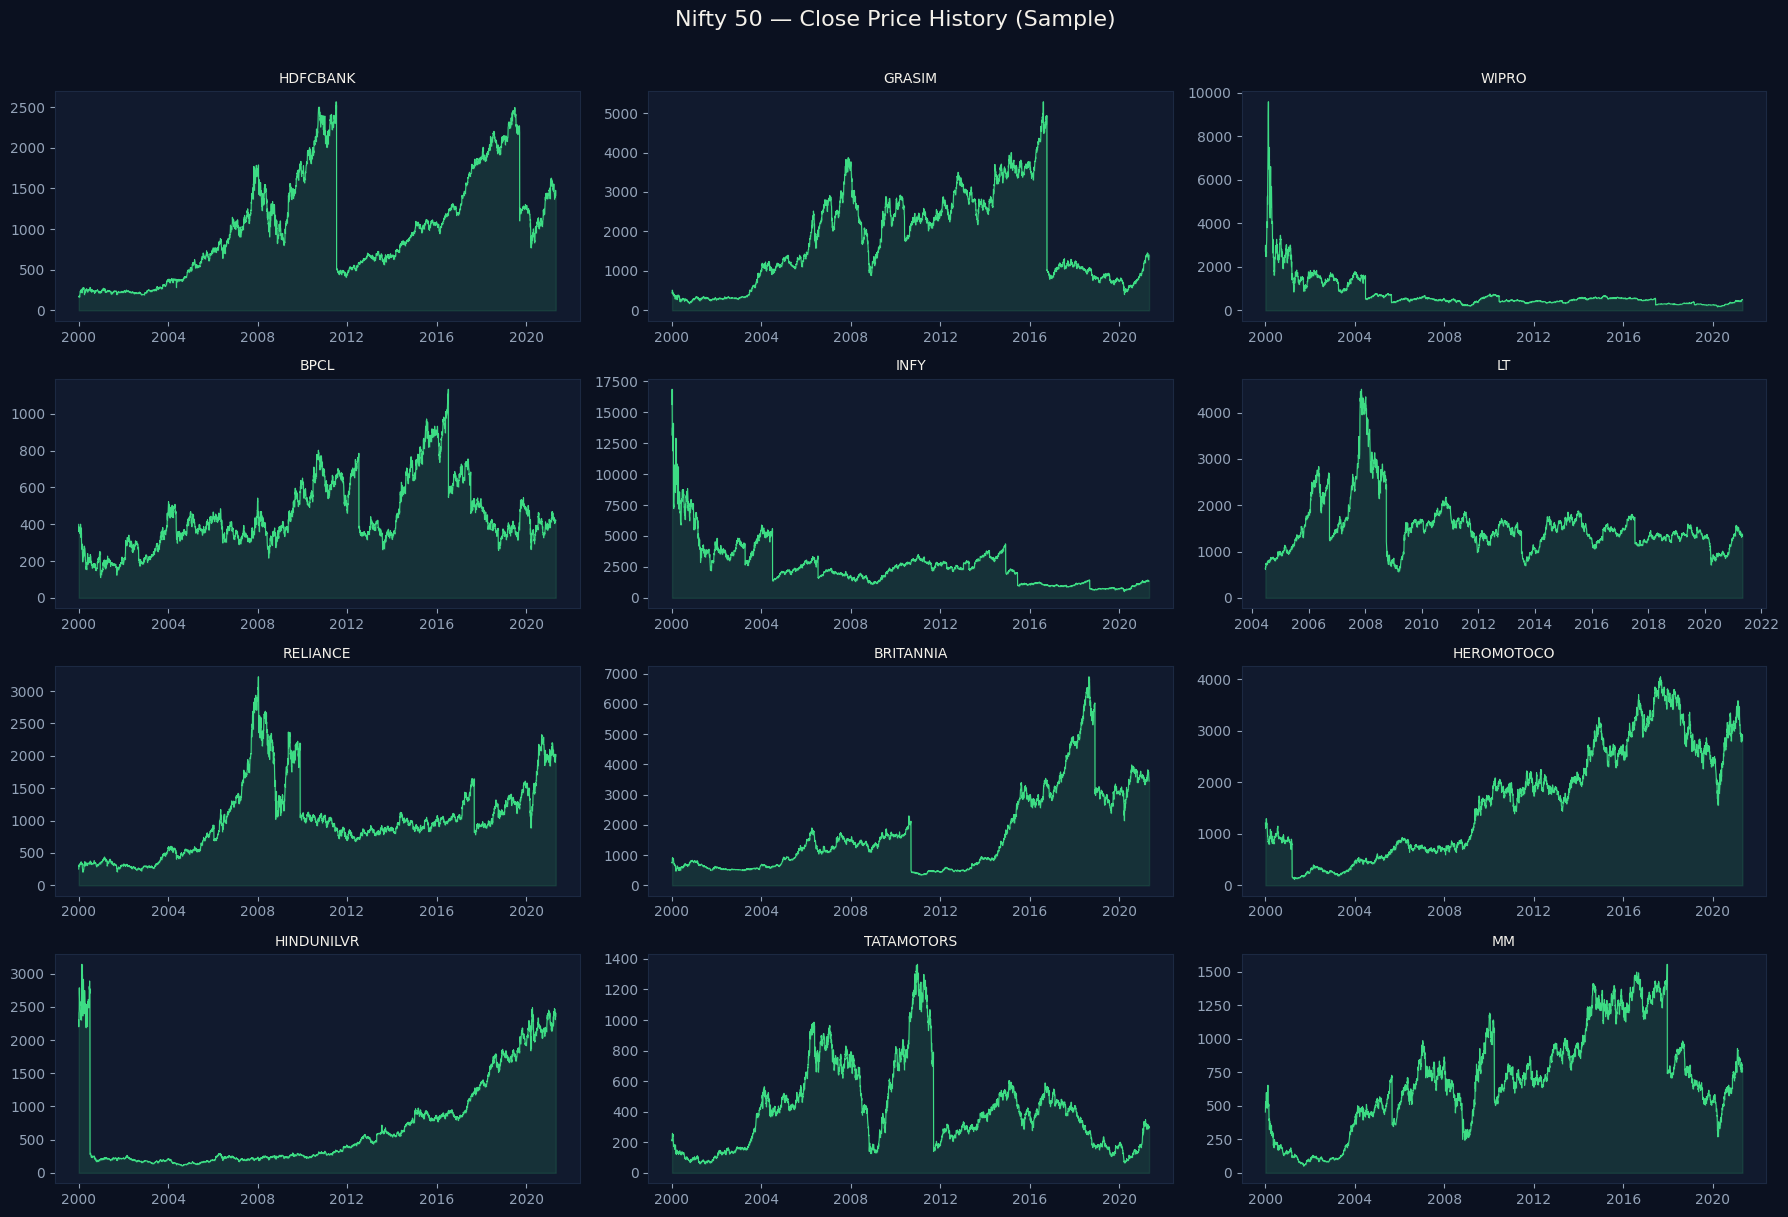

✓ Price history plot saved


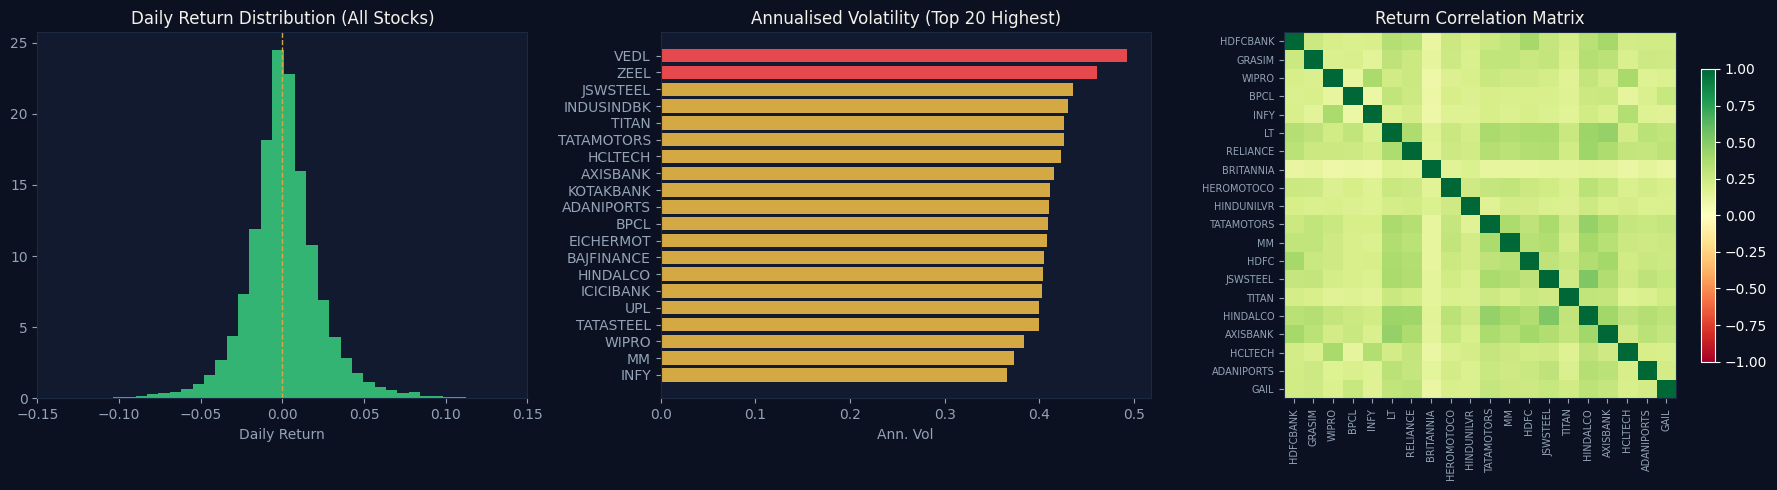

✓ Return analysis plot saved


In [3]:
# ### 2.1 EDA Visualizations

# %%
# — Price history panel for a sample of tickers
sample_tickers = list(ohlcv.keys())[:12]
fig, axes = plt.subplots(4, 3, figsize=(18, 12))
fig.suptitle("Nifty 50 — Close Price History (Sample)", fontsize=16, color=WHITE, y=1.01)
apply_dark_style(fig)
for ax, ticker in zip(axes.flat, sample_tickers):
    df = ohlcv[ticker]
    ax.plot(df.index, df["Close"], color=GREEN, linewidth=0.8)
    ax.fill_between(df.index, df["Close"], alpha=0.12, color=GREEN)
    ax.set_title(ticker.replace(".NS",""), fontsize=10)
    apply_dark_style(fig, ax)
plt.tight_layout()
plt.savefig("/kaggle/working/eda_price_history.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("✓ Price history plot saved")

# %%
# — Return distribution across all stocks
all_daily_rets = []
for df in ohlcv.values():
    rets = df["Close"].pct_change().dropna().values
    all_daily_rets.extend(rets.tolist())
all_daily_rets = np.array(all_daily_rets)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
apply_dark_style(fig)

axes[0].hist(all_daily_rets, bins=200, color=GREEN, alpha=0.8, density=True)
axes[0].axvline(0, color=GOLD, linestyle="--", linewidth=1)
axes[0].set_title("Daily Return Distribution (All Stocks)")
axes[0].set_xlabel("Daily Return")
axes[0].set_xlim(-0.15, 0.15)
apply_dark_style(fig, axes[0])

# Rolling vol per stock
vols = []
for ticker, df in ohlcv.items():
    v = df["Close"].pct_change().rolling(20).std().dropna().mean() * np.sqrt(252)
    vols.append((ticker.replace(".NS",""), v))
vols.sort(key=lambda x: x[1])
tnames, vvals = zip(*vols)
colors_ = [GREEN if v < 0.30 else GOLD if v < 0.45 else RED for v in vvals]
axes[1].barh(list(tnames)[-20:], list(vvals)[-20:], color=colors_[-20:])
axes[1].set_title("Annualised Volatility (Top 20 Highest)")
axes[1].set_xlabel("Ann. Vol")
apply_dark_style(fig, axes[1])

# Correlation heatmap (close returns)
close_df = pd.DataFrame({t.replace(".NS",""): ohlcv[t]["Close"].pct_change() for t in list(ohlcv.keys())[:20]}).dropna()
corr = close_df.corr()
im = axes[2].imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
axes[2].set_xticks(range(len(corr.columns)))
axes[2].set_yticks(range(len(corr.columns)))
axes[2].set_xticklabels(corr.columns, rotation=90, fontsize=7)
axes[2].set_yticklabels(corr.columns, fontsize=7)
axes[2].set_title("Return Correlation Matrix")
plt.colorbar(im, ax=axes[2], shrink=0.8)
apply_dark_style(fig, axes[2])

plt.tight_layout()
plt.savefig("/kaggle/working/eda_returns.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("✓ Return analysis plot saved")

✓ 20/20 indicators computed


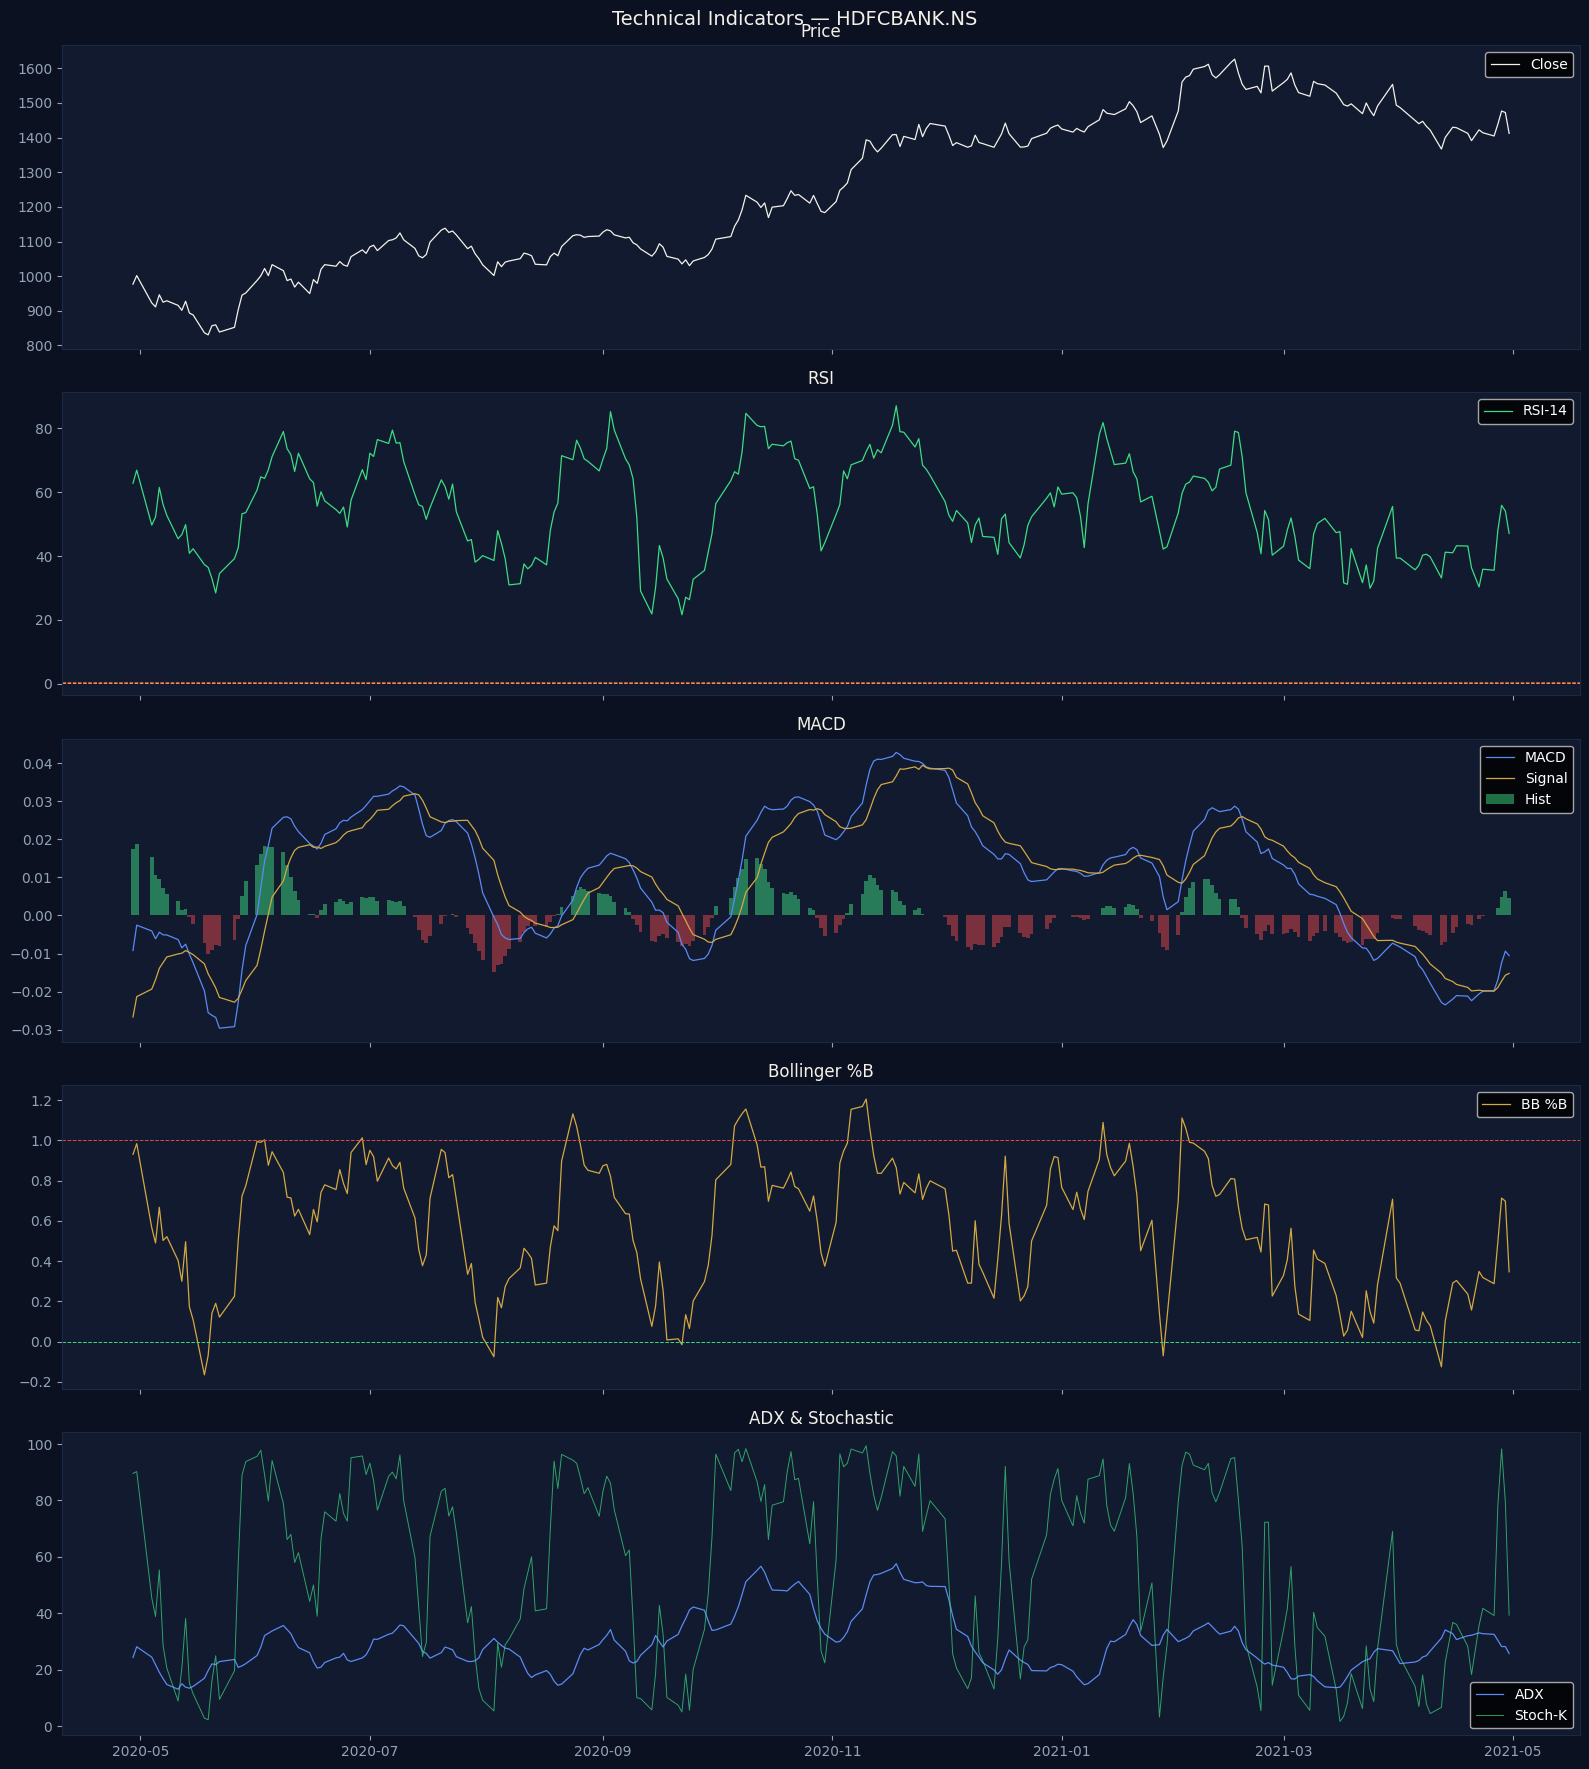

✓ Indicator chart saved


In [4]:
# ## 3. Technical Indicator Pipeline

# %%
try:
    import pandas_ta as ta_lib
    USE_PANDAS_TA = True
except ImportError:
    USE_PANDAS_TA = False
    print("pandas_ta not available; using manual indicator computation")

TA_FEATURES = [
    "rsi_14","rsi_21","macd","macd_hist","macd_signal",
    "bb_upper","bb_lower","bb_width","bb_pct","atr_14",
    "obv_norm","vwap_proxy","sma_20","sma_50","ema_21",
    "stoch_k","stoch_d","adx_14","cci_14","roc_10",
]

def compute_indicators(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    close, high, low, vol = out["Close"], out["High"], out["Low"], out["Volume"]

    def ema(s, n): return s.ewm(span=n, adjust=False).mean()
    def rsi(s, n=14):
        d = s.diff()
        gain = d.clip(lower=0).rolling(n).mean()
        loss = (-d.clip(upper=0)).rolling(n).mean()
        rs = gain / (loss + 1e-8)
        return 100 - 100/(1+rs)

    out["rsi_14"] = rsi(close, 14) / 100.0
    out["rsi_21"] = rsi(close, 21) / 100.0

    ema12 = ema(close, 12); ema26 = ema(close, 26)
    macd_line = ema12 - ema26
    signal_line = ema(macd_line, 9)
    out["macd"]        = macd_line / (close + 1e-8)
    out["macd_signal"] = signal_line / (close + 1e-8)
    out["macd_hist"]   = (macd_line - signal_line) / (close + 1e-8)

    bb_mid = close.rolling(20).mean()
    bb_std = close.rolling(20).std()
    bb_u   = bb_mid + 2*bb_std
    bb_l   = bb_mid - 2*bb_std
    out["bb_upper"] = (bb_u - close) / (close + 1e-8)
    out["bb_lower"] = (close - bb_l) / (close + 1e-8)
    out["bb_width"] = (bb_u - bb_l) / (bb_mid + 1e-8)
    out["bb_pct"]   = (close - bb_l) / (bb_u - bb_l + 1e-8)

    tr = pd.concat([high-low, (high-close.shift()).abs(), (low-close.shift()).abs()], axis=1).max(axis=1)
    out["atr_14"] = tr.rolling(14).mean() / (close + 1e-8)

    obv = (np.sign(close.diff()) * vol).fillna(0).cumsum()
    out["obv_norm"] = obv / (obv.rolling(20).mean().abs() + 1e-8)

    typical = (high + low + close) / 3
    vwap = (typical * vol).rolling(20).sum() / (vol.rolling(20).sum() + 1e-8)
    out["vwap_proxy"] = (close - vwap) / (vwap + 1e-8)

    out["sma_20"] = (close - close.rolling(20).mean()) / (close.rolling(20).mean() + 1e-8)
    out["sma_50"] = (close - close.rolling(50).mean()) / (close.rolling(50).mean() + 1e-8)
    out["ema_21"] = (close - ema(close, 21)) / (ema(close, 21) + 1e-8)

    low14  = low.rolling(14).min()
    high14 = high.rolling(14).max()
    out["stoch_k"] = (close - low14) / (high14 - low14 + 1e-8)
    out["stoch_d"] = out["stoch_k"].rolling(3).mean()

    plus_dm  = high.diff().clip(lower=0)
    minus_dm = (-low.diff()).clip(lower=0)
    atr14    = tr.rolling(14).mean()
    plus_di  = 100 * ema(plus_dm, 14) / (atr14 + 1e-8)
    minus_di = 100 * ema(minus_dm, 14) / (atr14 + 1e-8)
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di + 1e-8)
    out["adx_14"] = ema(dx, 14) / 100.0

    tp = (high + low + close) / 3
    mad = tp.rolling(14).apply(lambda x: np.mean(np.abs(x - x.mean())), raw=True)
    out["cci_14"] = (tp - tp.rolling(14).mean()) / (0.015 * mad + 1e-8) / 200.0

    out["roc_10"] = close.pct_change(10)

    return out

# Test
sample_df = list(ohlcv.values())[0]
test_ind = compute_indicators(sample_df)
available_ta = [f for f in TA_FEATURES if f in test_ind.columns]
print(f"✓ {len(available_ta)}/{len(TA_FEATURES)} indicators computed")

# %%
# — Visualise indicators for one stock
ticker_viz = list(ohlcv.keys())[0]
df_viz = compute_indicators(ohlcv[ticker_viz]).tail(252)

fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)
apply_dark_style(fig)
fig.suptitle(f"Technical Indicators — {ticker_viz}", fontsize=14, color=WHITE)

axes[0].plot(df_viz.index, ohlcv[ticker_viz].loc[df_viz.index, "Close"], color=WHITE, lw=0.9, label="Close")
axes[0].set_title("Price"); axes[0].legend()
apply_dark_style(fig, axes[0])

axes[1].plot(df_viz.index, df_viz["rsi_14"]*100, color=GREEN, lw=0.9, label="RSI-14")
axes[1].axhline(0.7, color=RED, linestyle="--", lw=0.7)
axes[1].axhline(0.3, color=GOLD, linestyle="--", lw=0.7)
axes[1].set_title("RSI"); axes[1].legend()
apply_dark_style(fig, axes[1])

axes[2].plot(df_viz.index, df_viz["macd"], color=BLUE, lw=0.9, label="MACD")
axes[2].plot(df_viz.index, df_viz["macd_signal"], color=GOLD, lw=0.9, label="Signal")
axes[2].bar(df_viz.index, df_viz["macd_hist"], color=[GREEN if v>0 else RED for v in df_viz["macd_hist"]], alpha=0.5, label="Hist", width=1)
axes[2].set_title("MACD"); axes[2].legend()
apply_dark_style(fig, axes[2])

axes[3].plot(df_viz.index, df_viz["bb_pct"], color=GOLD, lw=0.9, label="BB %B")
axes[3].axhline(1, color=RED, linestyle="--", lw=0.7)
axes[3].axhline(0, color=GREEN, linestyle="--", lw=0.7)
axes[3].set_title("Bollinger %B"); axes[3].legend()
apply_dark_style(fig, axes[3])

axes[4].plot(df_viz.index, df_viz["adx_14"]*100, color=BLUE, lw=0.9, label="ADX")
axes[4].plot(df_viz.index, df_viz["stoch_k"]*100, color=GREEN, lw=0.7, label="Stoch-K", alpha=0.7)
axes[4].set_title("ADX & Stochastic"); axes[4].legend()
apply_dark_style(fig, axes[4])

plt.tight_layout()
plt.savefig("/kaggle/working/indicators_sample.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("✓ Indicator chart saved")


Feature matrix: (234815, 20), label mean=0.00166, std=0.0558
Features: ['rsi_14', 'rsi_21', 'macd', 'macd_hist', 'macd_signal', 'bb_upper', 'bb_lower', 'bb_width', 'bb_pct', 'atr_14', 'obv_norm', 'vwap_proxy', 'sma_20', 'sma_50', 'ema_21', 'stoch_k', 'stoch_d', 'adx_14', 'cci_14', 'roc_10']


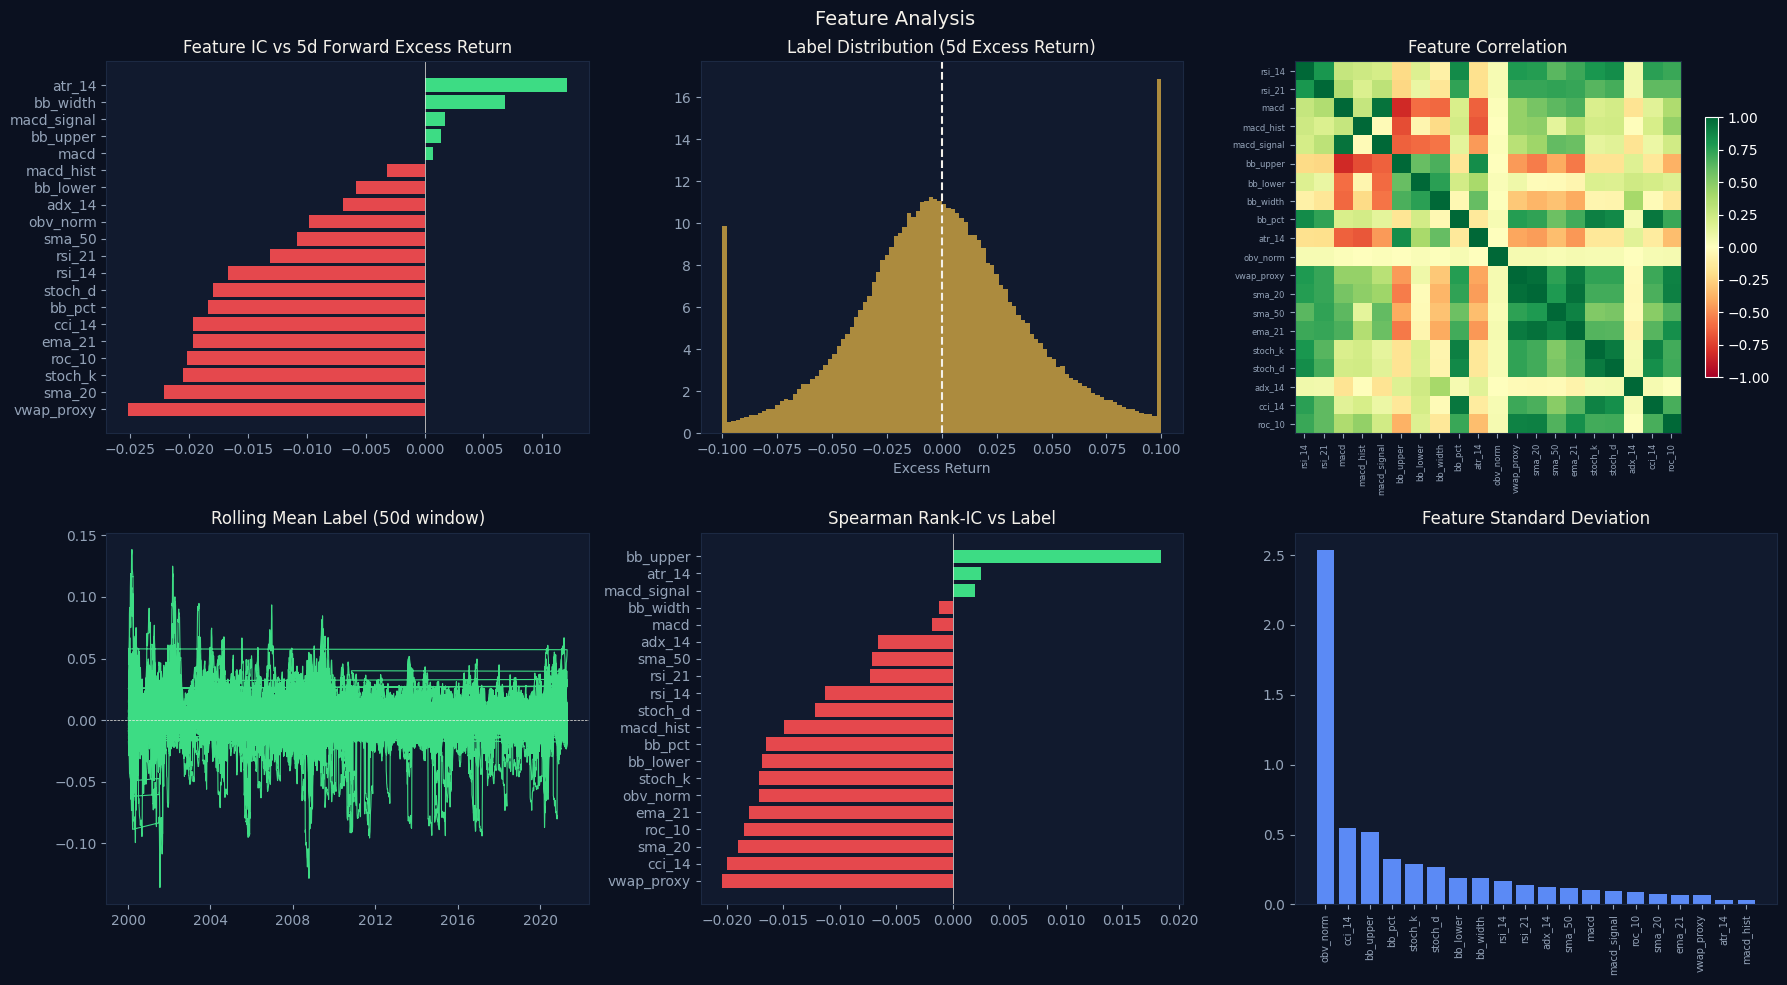

✓ Feature analysis saved


In [5]:
# ## 4. Feature Matrix Construction

# %%
def build_feature_matrix(
    ohlcv_dict: dict[str, pd.DataFrame],
    label_horizon: int = LABEL_HORIZON,
) -> tuple[pd.DataFrame, pd.Series, pd.Series]:
    """Build stacked (date, ticker) feature matrix for ML models.
    Returns X, y (excess return), raw_return."""
    frames = []
    # Build a simple NIFTY proxy from all stocks' mean return
    all_closes = pd.DataFrame({t: ohlcv_dict[t]["Close"] for t in ohlcv_dict}).dropna(how="all")
    nifty_proxy = all_closes.mean(axis=1).pct_change()
    nifty_fwd   = nifty_proxy.shift(-label_horizon).rolling(label_horizon).sum()

    for ticker, df in ohlcv_dict.items():
        try:
            ind = compute_indicators(df)
            ta_cols = [c for c in TA_FEATURES if c in ind.columns]
            feat = ind[ta_cols].copy().shift(1)  # lag-1 to prevent look-ahead

            fwd_ret = df["Close"].pct_change(label_horizon).shift(-label_horizon)
            excess  = fwd_ret - nifty_fwd.reindex(fwd_ret.index, fill_value=0)

            feat["_ticker"] = ticker
            feat["_label"]  = excess
            feat["_raw"]    = fwd_ret
            frames.append(feat)
        except Exception as e:
            logger.warning("Feature build failed for %s: %s", ticker, e)

    combined = pd.concat(frames).dropna(subset=["_label"])
    feature_cols = [c for c in combined.columns if c not in ("_ticker","_label","_raw")]
    X = combined[feature_cols].fillna(combined[feature_cols].median())
    y = combined["_label"]
    raw = combined["_raw"]
    print(f"Feature matrix: {X.shape}, label mean={y.mean():.5f}, std={y.std():.4f}")
    return X, y, raw

X, y, y_raw = build_feature_matrix(ohlcv)
FEATURE_NAMES = list(X.columns)
print(f"Features: {FEATURE_NAMES}")

# %%
# — Feature distribution & correlation with label
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
apply_dark_style(fig)
fig.suptitle("Feature Analysis", fontsize=14, color=WHITE)

# IC of each feature vs label
ics = {}
for col in FEATURE_NAMES:
    valid = (~X[col].isna()) & (~y.isna())
    if valid.sum() > 30:
        ic, _ = pearsonr(X.loc[valid, col], y[valid])
        ics[col] = ic

ic_series = pd.Series(ics).sort_values()
colors_ = [GREEN if v > 0 else RED for v in ic_series.values]
axes[0,0].barh(ic_series.index, ic_series.values, color=colors_)
axes[0,0].axvline(0, color=WHITE, linewidth=0.5)
axes[0,0].set_title("Feature IC vs 5d Forward Excess Return")
apply_dark_style(fig, axes[0,0])

# Label distribution
axes[0,1].hist(y.clip(-0.1, 0.1), bins=100, color=GOLD, alpha=0.8, density=True)
axes[0,1].axvline(0, color=WHITE, linestyle="--")
axes[0,1].set_title("Label Distribution (5d Excess Return)")
axes[0,1].set_xlabel("Excess Return")
apply_dark_style(fig, axes[0,1])

# Feature correlation heatmap
feat_corr = X.corr()
im = axes[0,2].imshow(feat_corr.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
axes[0,2].set_title("Feature Correlation")
axes[0,2].set_xticks(range(len(FEATURE_NAMES)))
axes[0,2].set_yticks(range(len(FEATURE_NAMES)))
axes[0,2].set_xticklabels(FEATURE_NAMES, rotation=90, fontsize=6)
axes[0,2].set_yticklabels(FEATURE_NAMES, fontsize=6)
plt.colorbar(im, ax=axes[0,2], shrink=0.7)
apply_dark_style(fig, axes[0,2])

# Rolling label mean
y_roll = y.rolling(50).mean()
axes[1,0].plot(y.index[:len(y_roll)], y_roll.values, color=GREEN, lw=0.8)
axes[1,0].axhline(0, color=WHITE, linestyle="--", lw=0.5)
axes[1,0].set_title("Rolling Mean Label (50d window)")
apply_dark_style(fig, axes[1,0])

# Spearman rank IC
sics = {}
for col in FEATURE_NAMES:
    valid = (~X[col].isna()) & (~y.isna())
    if valid.sum() > 30:
        sic, _ = spearmanr(X.loc[valid, col], y[valid])
        sics[col] = sic
sic_series = pd.Series(sics).sort_values()
colors_ = [GREEN if v > 0 else RED for v in sic_series.values]
axes[1,1].barh(sic_series.index, sic_series.values, color=colors_)
axes[1,1].axvline(0, color=WHITE, linewidth=0.5)
axes[1,1].set_title("Spearman Rank-IC vs Label")
apply_dark_style(fig, axes[1,1])

# Feature variance
feat_std = X.std().sort_values(ascending=False)
axes[1,2].bar(range(len(feat_std)), feat_std.values, color=BLUE)
axes[1,2].set_xticks(range(len(feat_std)))
axes[1,2].set_xticklabels(feat_std.index, rotation=90, fontsize=7)
axes[1,2].set_title("Feature Standard Deviation")
apply_dark_style(fig, axes[1,2])

plt.tight_layout()
plt.savefig("/kaggle/working/feature_analysis.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("✓ Feature analysis saved")



HMM features shape: (5227, 4)


2026-06-27 13:19:17,028 INFO HMM state map: {0: 'bull', 3: 'bear', 1: 'high_vol', 2: 'ranging'}
2026-06-27 13:19:17,029 INFO   State 0 (bull): ret=0.0023 vol=0.1710 n=1452
2026-06-27 13:19:17,030 INFO   State 1 (high_vol): ret=-0.0010 vol=0.1695 n=1415
2026-06-27 13:19:17,031 INFO   State 2 (ranging): ret=0.0014 vol=0.1320 n=1206
2026-06-27 13:19:17,032 INFO   State 3 (bear): ret=-0.0016 vol=0.4106 n=1154


✓ HMM trained. Log-likelihood: -19278.75
  State map: {0: 'bull', 3: 'bear', 1: 'high_vol', 2: 'ranging'}
✓ HMM saved


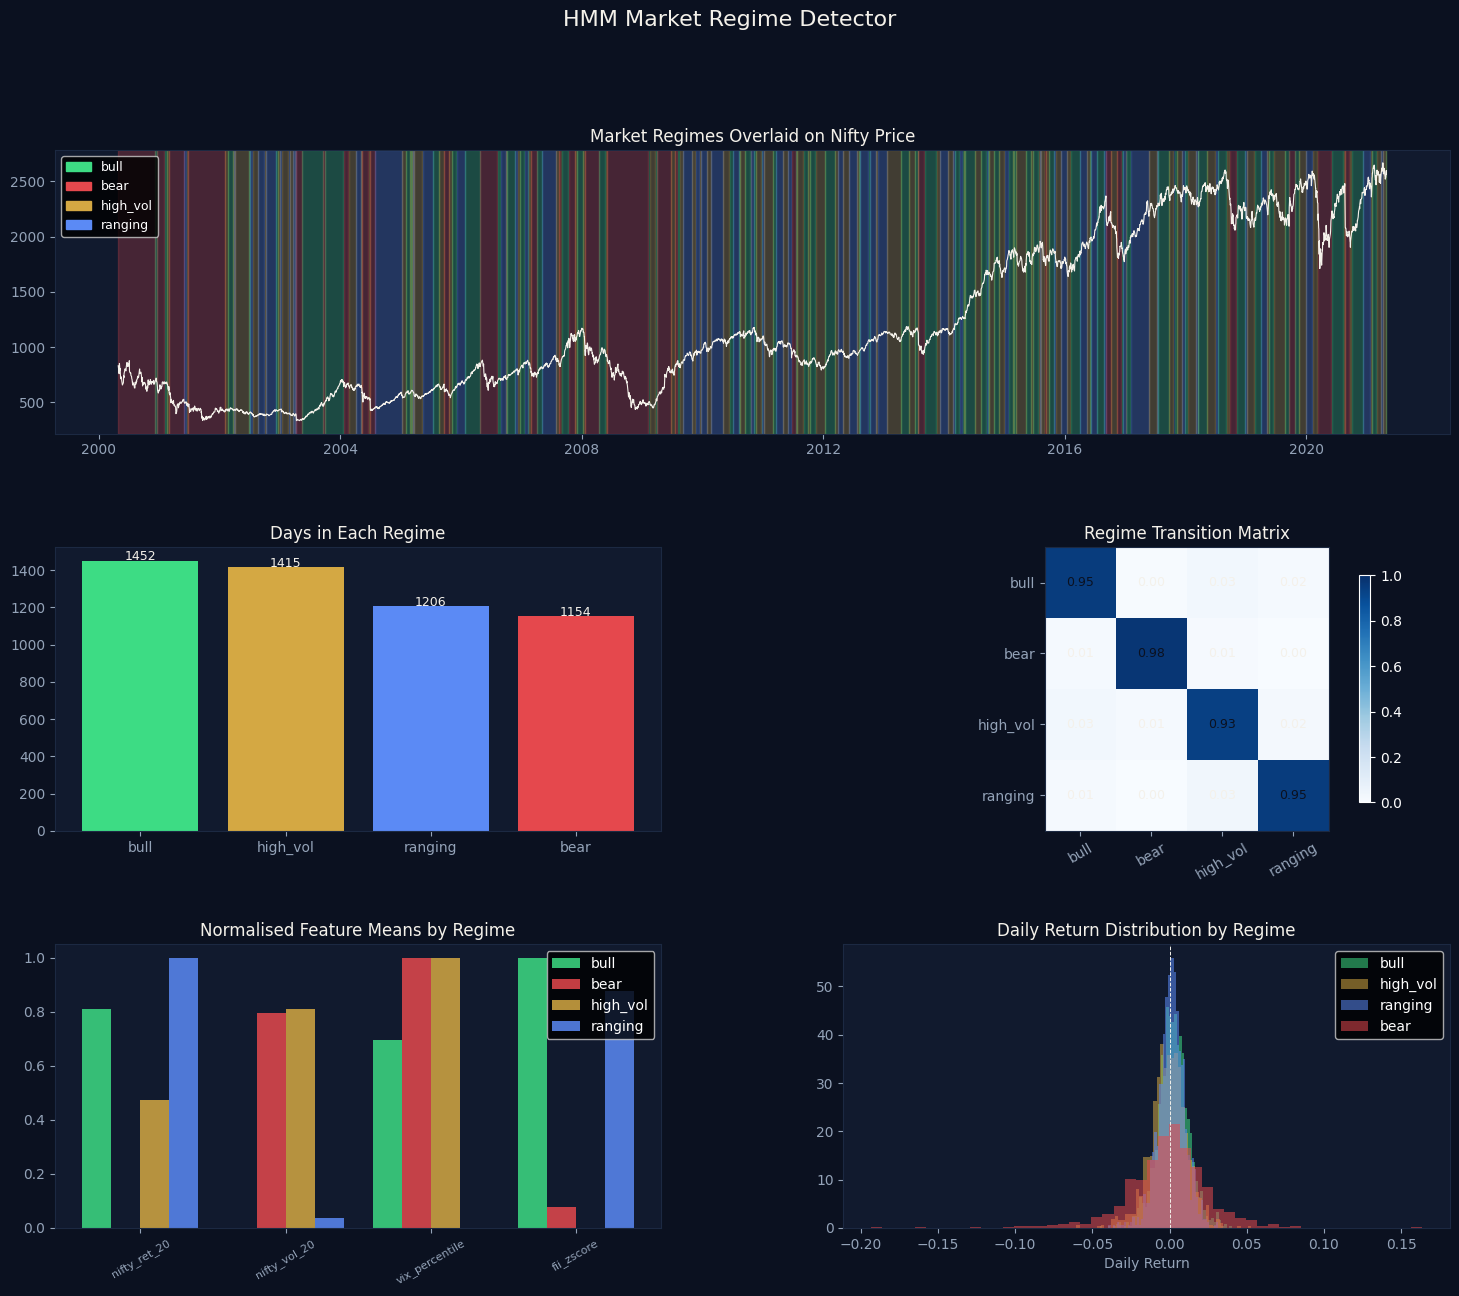

✓ HMM analysis saved


In [6]:
# ## 5. HMM Market Regime Detector

# %%
def build_hmm_features(ohlcv_dict: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Build 4-dim HMM feature matrix from market data."""
    all_closes = pd.DataFrame({t: ohlcv_dict[t]["Close"] for t in ohlcv_dict}).dropna(how="all")
    nifty = all_closes.mean(axis=1)
    nifty_ret = nifty.pct_change()
    nifty_vol = nifty_ret.rolling(20).std() * np.sqrt(252)
    nifty_ret_20 = nifty_ret.rolling(20).mean() * 252  # annualised

    # VIX proxy: cross-sectional vol of daily returns
    daily_rets = all_closes.pct_change()
    vix_proxy = daily_rets.std(axis=1).rolling(20).mean() * np.sqrt(252)
    vix_pct = vix_proxy.rolling(252, min_periods=60).rank(pct=True)

    # FII proxy: 20-day momentum z-score as institutional flow proxy
    mom20 = nifty_ret.rolling(20).sum()
    fii_z = (mom20 - mom20.rolling(60).mean()) / (mom20.rolling(60).std() + 1e-8)

    feat_df = pd.DataFrame({
        "nifty_ret_20":  nifty_ret_20,
        "nifty_vol_20":  nifty_vol,
        "vix_percentile":vix_pct,
        "fii_zscore":    fii_z,
    }).dropna()
    return feat_df, nifty_ret

hmm_features, nifty_ret_series = build_hmm_features(ohlcv)
print(f"HMM features shape: {hmm_features.shape}")

# %%
def train_hmm(feat_df: pd.DataFrame, n_states: int = HMM_N_STATES) -> tuple:
    """Train Gaussian HMM with multiple restarts. Returns model, scaler, state_map."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(feat_df.values)

    best_model, best_score = None, -np.inf
    for trial in range(10):
        try:
            model = GaussianHMM(n_components=n_states, covariance_type="diag",
                                n_iter=200, random_state=trial)
            model.fit(X_scaled)
            score = model.score(X_scaled)
            if score > best_score:
                best_score, best_model = score, model
        except Exception as e:
            continue

    assert best_model is not None, "HMM failed to converge"
    states = best_model.predict(X_scaled)

    # Assign names by mean return
    nifty_aligned = nifty_ret_series.reindex(feat_df.index, method="ffill").fillna(0)
    state_stats = {}
    for s in range(n_states):
        mask = states == s
        state_stats[s] = {
            "mean_ret": float(nifty_aligned.values[mask].mean()),
            "mean_vol": float(feat_df["nifty_vol_20"].values[mask].mean()),
            "n": int(mask.sum()),
        }

    sorted_ret = sorted(state_stats, key=lambda s: state_stats[s]["mean_ret"], reverse=True)
    sorted_vol = sorted(state_stats, key=lambda s: state_stats[s]["mean_vol"], reverse=True)

    state_map = {}
    state_map[sorted_ret[0]]  = "bull"
    state_map[sorted_ret[-1]] = "bear"
    remaining = [s for s in range(n_states) if s not in state_map]
    high_vol_s = max(remaining, key=lambda s: state_stats[s]["mean_vol"])
    state_map[high_vol_s] = "high_vol"
    for s in remaining:
        if s != high_vol_s:
            state_map[s] = "ranging"

    logger.info("HMM state map: %s", state_map)
    for s, st in state_stats.items():
        logger.info("  State %d (%s): ret=%.4f vol=%.4f n=%d",
                    s, state_map.get(s,"?"), st["mean_ret"], st["mean_vol"], st["n"])

    diag = np.diag(best_model.transmat_)
    if np.any(diag < 0.7):
        logger.warning("Low transition diagonal: %s", np.round(diag,3))
    return best_model, scaler, state_map, states, state_stats, best_score

hmm_model, hmm_scaler, state_map, hmm_states, state_stats, hmm_score = train_hmm(hmm_features)
print(f"✓ HMM trained. Log-likelihood: {hmm_score:.2f}")
print(f"  State map: {state_map}")

joblib.dump({"model": hmm_model, "scaler": hmm_scaler, "state_map": state_map},
            OUTPUT_DIR / "hmm_regime.pkl")
print("✓ HMM saved")

# %%
# — HMM Visualizations
REGIME_COLORS = {"bull": GREEN, "bear": RED, "high_vol": GOLD, "ranging": BLUE}
regime_names_hist = [state_map[int(s)] for s in hmm_states]

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)
apply_dark_style(fig)
fig.suptitle("HMM Market Regime Detector", fontsize=16, color=WHITE)

# 1. Regime timeline
ax0 = fig.add_subplot(gs[0, :])
nifty_price = pd.DataFrame({t: ohlcv[t]["Close"] for t in ohlcv}).mean(axis=1)
nifty_aligned_price = nifty_price.reindex(hmm_features.index)
ax0.plot(hmm_features.index, nifty_aligned_price.values, color=WHITE, lw=0.8, zorder=5)
prev = 0
for i in range(1, len(regime_names_hist)):
    if regime_names_hist[i] != regime_names_hist[i-1] or i == len(regime_names_hist)-1:
        color = REGIME_COLORS.get(regime_names_hist[prev], SLATE)
        ax0.axvspan(hmm_features.index[prev], hmm_features.index[i-1], alpha=0.25, color=color)
        prev = i
patches = [mpatches.Patch(color=c, label=k) for k,c in REGIME_COLORS.items()]
ax0.legend(handles=patches, loc="upper left", fontsize=9)
ax0.set_title("Market Regimes Overlaid on Nifty Price")
apply_dark_style(fig, ax0)

# 2. State distribution
ax1 = fig.add_subplot(gs[1, 0])
regime_counts = pd.Series(regime_names_hist).value_counts()
bars = ax1.bar(regime_counts.index, regime_counts.values,
               color=[REGIME_COLORS.get(r, SLATE) for r in regime_counts.index])
ax1.set_title("Days in Each Regime")
for bar, cnt in zip(bars, regime_counts.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, str(cnt),
             ha="center", fontsize=9, color=WHITE)
apply_dark_style(fig, ax1)

# 3. Transition matrix
ax2 = fig.add_subplot(gs[1, 1])
ordered = ["bull","bear","high_vol","ranging"]
state_idx_ordered = [k for r in ordered for k,v in state_map.items() if v == r]
trans = hmm_model.transmat_[np.ix_(state_idx_ordered, state_idx_ordered)]
im = ax2.imshow(trans, cmap="Blues", vmin=0, vmax=1)
ax2.set_xticks(range(len(ordered))); ax2.set_yticks(range(len(ordered)))
ax2.set_xticklabels(ordered, rotation=30); ax2.set_yticklabels(ordered)
for i in range(len(ordered)):
    for j in range(len(ordered)):
        ax2.text(j, i, f"{trans[i,j]:.2f}", ha="center", va="center",
                 color=WHITE if trans[i,j] < 0.5 else DARK_BG, fontsize=9)
ax2.set_title("Regime Transition Matrix")
plt.colorbar(im, ax=ax2, shrink=0.8)
apply_dark_style(fig, ax2)

# 4. Feature means per regime
ax3 = fig.add_subplot(gs[2, 0])
feat_means = {}
for s in range(HMM_N_STATES):
    name = state_map[s]
    mask = hmm_states == s
    feat_means[name] = hmm_features.values[mask].mean(axis=0)
feat_mean_df = pd.DataFrame(feat_means, index=hmm_features.columns)
feat_mean_df_norm = (feat_mean_df - feat_mean_df.min()) / (feat_mean_df.max() - feat_mean_df.min() + 1e-8)
x_ = np.arange(len(hmm_features.columns))
for i, (regime, color) in enumerate(REGIME_COLORS.items()):
    if regime in feat_mean_df_norm.columns:
        ax3.bar(x_ + i*0.2, feat_mean_df_norm[regime], 0.2, color=color, label=regime, alpha=0.85)
ax3.set_xticks(x_ + 0.3)
ax3.set_xticklabels(hmm_features.columns, rotation=30, fontsize=8)
ax3.legend(); ax3.set_title("Normalised Feature Means by Regime")
apply_dark_style(fig, ax3)

# 5. Return distribution per regime
ax4 = fig.add_subplot(gs[2, 1])
for s in range(HMM_N_STATES):
    name = state_map[s]
    mask = hmm_states == s
    ret_s = nifty_ret_series.reindex(hmm_features.index).values[mask]
    ret_s = ret_s[~np.isnan(ret_s)]
    if len(ret_s) > 5:
        ax4.hist(ret_s, bins=50, alpha=0.55, density=True,
                 color=REGIME_COLORS[name], label=name)
ax4.axvline(0, color=WHITE, linestyle="--", lw=0.7)
ax4.legend(); ax4.set_title("Daily Return Distribution by Regime")
ax4.set_xlabel("Daily Return")
apply_dark_style(fig, ax4)

plt.savefig("/kaggle/working/hmm_analysis.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("✓ HMM analysis saved")


Running 5-fold purged CV...
  Fold 1/5: IC=0.0071, RMSE=0.05657, best_iter=1
  Fold 2/5: IC=0.0549, RMSE=0.06045, best_iter=22
  Fold 3/5: IC=0.0620, RMSE=0.05286, best_iter=91
  Fold 4/5: IC=0.0598, RMSE=0.05538, best_iter=41
  Fold 5/5: IC=0.0678, RMSE=0.05423, best_iter=67

✓ LGBM CV complete | Mean IC=0.0503 | IC-IR=2.2885
✓ LGBM saved


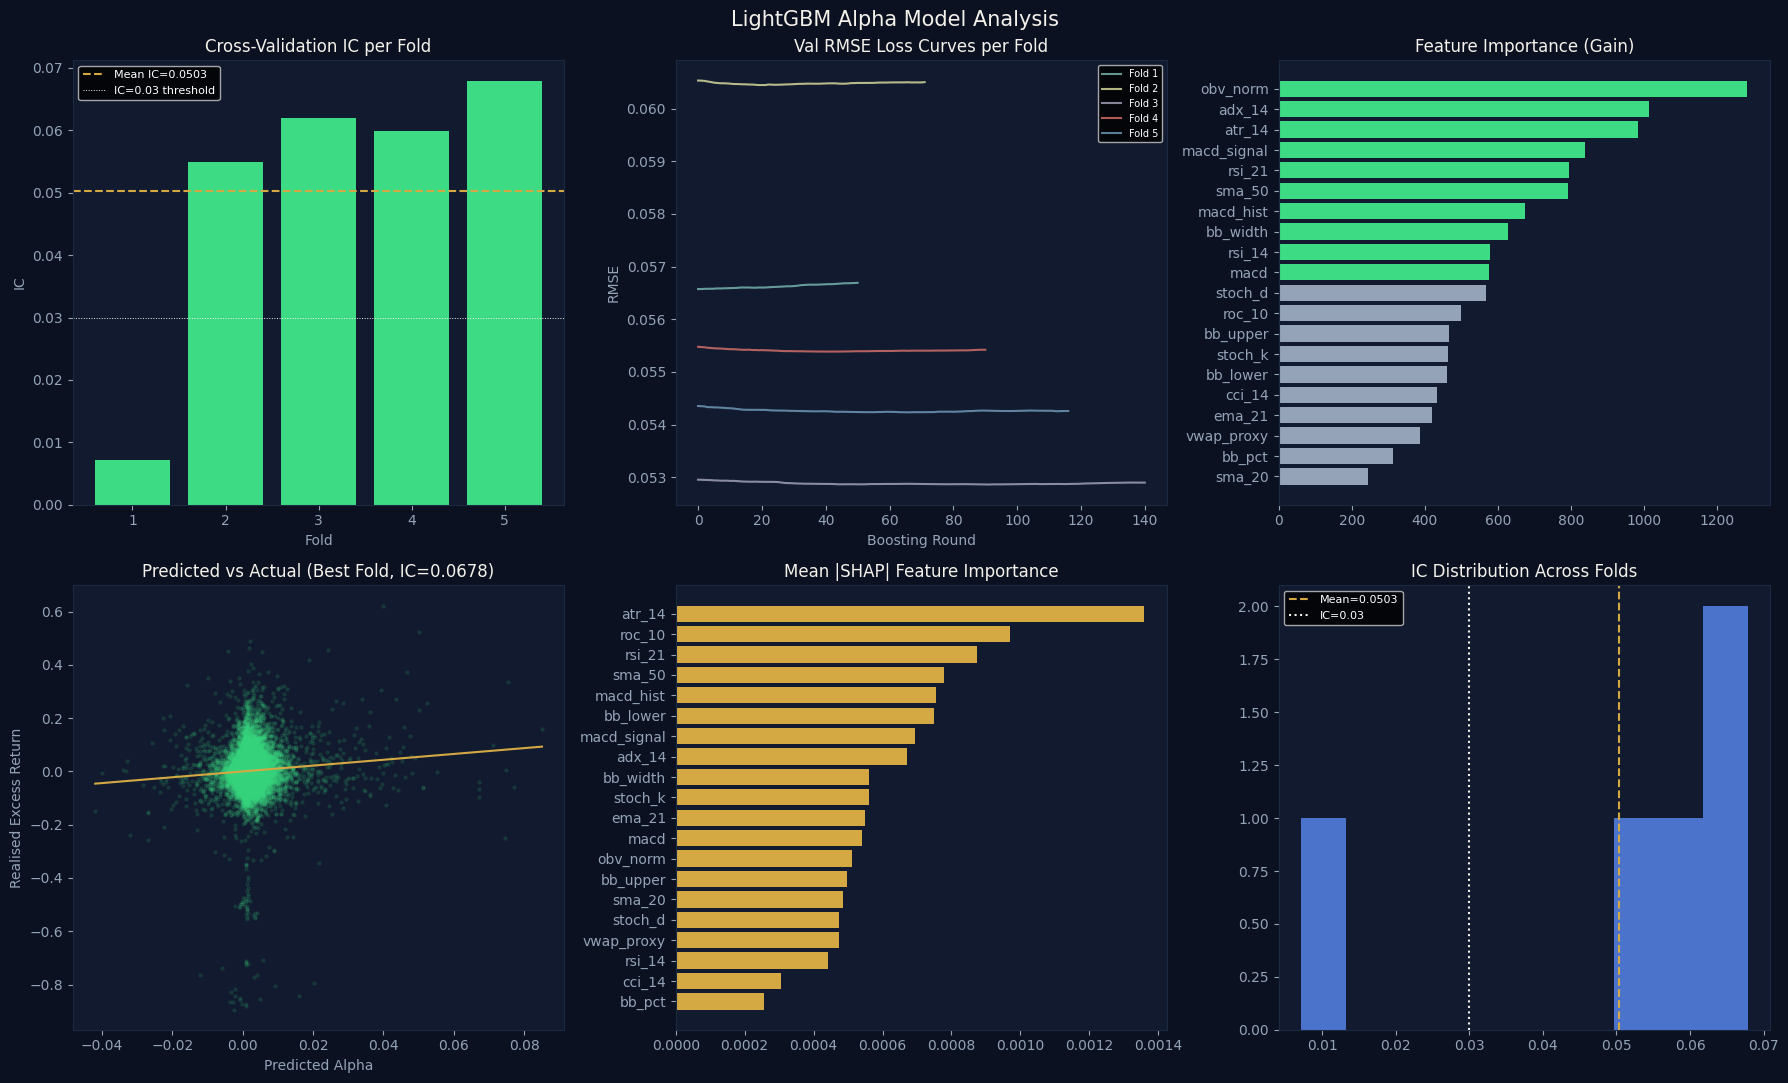

✓ LGBM analysis saved


In [7]:
# ## 6. LightGBM Alpha Model

# %%
def purged_cv_splits(n: int, n_splits: int = 5, embargo: int = WF_EMBARGO_DAYS):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    splits = []
    for tr, vl in tscv.split(np.arange(n)):
        purged = tr[tr < vl[0] - embargo]
        if len(purged) > 100:
            splits.append((purged, vl))
    return splits

# Scale features
lgbm_scaler = RobustScaler()
X_arr = lgbm_scaler.fit_transform(X.values).astype(np.float32)
y_arr = y.values.astype(np.float32)

splits = purged_cv_splits(len(X_arr))
lgbm_ic_scores, lgbm_val_rmses = [], []
best_lgbm, best_lgbm_ic = None, -np.inf
fold_histories = []

print(f"Running {len(splits)}-fold purged CV...")
for fold_idx, (tr_idx, vl_idx) in enumerate(splits):
    X_tr, X_vl = X_arr[tr_idx], X_arr[vl_idx]
    y_tr, y_vl = y_arr[tr_idx], y_arr[vl_idx]

    model = lgb.LGBMRegressor(**LGBM_PARAMS)
    history = {}
    callbacks = [
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(period=-1),
        lgb.record_evaluation(history),
    ]
    model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], callbacks=callbacks)

    vl_pred = model.predict(X_vl)
    ic = pearsonr(vl_pred, y_vl)[0] if len(vl_pred) > 2 else 0.0
    rmse = np.sqrt(mean_squared_error(y_vl, vl_pred))
    lgbm_ic_scores.append(ic)
    lgbm_val_rmses.append(rmse)
    fold_histories.append(history)

    if ic > best_lgbm_ic:
        best_lgbm_ic, best_lgbm = ic, model

    print(f"  Fold {fold_idx+1}/{len(splits)}: IC={ic:.4f}, RMSE={rmse:.5f}, "
          f"best_iter={model.best_iteration_}")

mean_ic = np.mean(lgbm_ic_scores)
ic_ir   = mean_ic / (np.std(lgbm_ic_scores) + 1e-8)
print(f"\n✓ LGBM CV complete | Mean IC={mean_ic:.4f} | IC-IR={ic_ir:.4f}")

# Final model on full data
final_lgbm = lgb.LGBMRegressor(**{**LGBM_PARAMS, "n_estimators": 300})
final_lgbm.fit(X_arr, y_arr, callbacks=[lgb.log_evaluation(period=-1)])

joblib.dump({"model": final_lgbm, "scaler": lgbm_scaler, "feature_names": FEATURE_NAMES},
            OUTPUT_DIR / "lgbm_alpha.pkl")
print("✓ LGBM saved")

# %%
# — LGBM Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
apply_dark_style(fig)
fig.suptitle("LightGBM Alpha Model Analysis", fontsize=15, color=WHITE)

# 1. CV IC scores
axes[0,0].bar(range(1, len(lgbm_ic_scores)+1), lgbm_ic_scores,
              color=[GREEN if ic > 0 else RED for ic in lgbm_ic_scores])
axes[0,0].axhline(mean_ic, color=GOLD, linestyle="--", label=f"Mean IC={mean_ic:.4f}")
axes[0,0].axhline(0.03, color=WHITE, linestyle=":", linewidth=0.7, label="IC=0.03 threshold")
axes[0,0].set_xlabel("Fold"); axes[0,0].set_ylabel("IC")
axes[0,0].set_title("Cross-Validation IC per Fold")
axes[0,0].legend(fontsize=8)
apply_dark_style(fig, axes[0,0])

# 2. Val loss curves
for i, hist in enumerate(fold_histories):
    key = list(hist.keys())[0] if hist else None
    if key and "rmse" in hist[key]:
        axes[0,1].plot(hist[key]["rmse"], alpha=0.7, label=f"Fold {i+1}")
axes[0,1].set_title("Val RMSE Loss Curves per Fold")
axes[0,1].set_xlabel("Boosting Round"); axes[0,1].set_ylabel("RMSE")
axes[0,1].legend(fontsize=7)
apply_dark_style(fig, axes[0,1])

# 3. Feature importance
fi = pd.Series(final_lgbm.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=True)
colors_ = [GREEN if fi[k] > fi.median() else SLATE for k in fi.index]
axes[0,2].barh(fi.index, fi.values, color=colors_)
axes[0,2].set_title("Feature Importance (Gain)")
apply_dark_style(fig, axes[0,2])

# 4. Predicted vs actual (validation of best fold)
best_fold_idx = np.argmax(lgbm_ic_scores)
tr_idx_b, vl_idx_b = splits[best_fold_idx]
vl_pred_b = best_lgbm.predict(X_arr[vl_idx_b])
vl_true_b = y_arr[vl_idx_b]
axes[1,0].scatter(vl_pred_b, vl_true_b, alpha=0.1, s=5, color=GREEN)
z = np.polyfit(vl_pred_b, vl_true_b, 1)
p = np.poly1d(z)
xr = np.linspace(vl_pred_b.min(), vl_pred_b.max(), 100)
axes[1,0].plot(xr, p(xr), color=GOLD, lw=1.5)
axes[1,0].set_xlabel("Predicted Alpha"); axes[1,0].set_ylabel("Realised Excess Return")
axes[1,0].set_title(f"Predicted vs Actual (Best Fold, IC={lgbm_ic_scores[best_fold_idx]:.4f})")
apply_dark_style(fig, axes[1,0])

# 5. SHAP summary (fast)
try:
    explainer = shap.TreeExplainer(final_lgbm)
    sample_idx = np.random.choice(len(X_arr), min(500, len(X_arr)), replace=False)
    shap_vals = explainer.shap_values(X_arr[sample_idx])
    shap_mean = np.abs(shap_vals).mean(axis=0)
    shap_series = pd.Series(shap_mean, index=FEATURE_NAMES).sort_values(ascending=True)
    axes[1,1].barh(shap_series.index, shap_series.values, color=GOLD)
    axes[1,1].set_title("Mean |SHAP| Feature Importance")
    apply_dark_style(fig, axes[1,1])
except Exception as e:
    axes[1,1].text(0.5, 0.5, f"SHAP failed:\n{e}", transform=axes[1,1].transAxes,
                   ha="center", color=SLATE)
    apply_dark_style(fig, axes[1,1])

# 6. IC distribution
axes[1,2].hist(lgbm_ic_scores, bins=10, color=BLUE, alpha=0.8)
axes[1,2].axvline(mean_ic, color=GOLD, linestyle="--", label=f"Mean={mean_ic:.4f}")
axes[1,2].axvline(0.03, color=WHITE, linestyle=":", label="IC=0.03")
axes[1,2].set_title("IC Distribution Across Folds")
axes[1,2].legend(fontsize=8)
apply_dark_style(fig, axes[1,2])

plt.tight_layout()
plt.savefig("/kaggle/working/lgbm_analysis.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("✓ LGBM analysis saved")



  KAN TRAINING  |  Device: cuda  |  Width: [20, 64, 32, 1]
  Grid: 15  |  Order: 3  |  LR: 0.0005  |  Batch: 256
  Folds: 5  |  Epochs: 20  |  Early Stop: 5



Overall CV:   0%|          | 0/5 folds [00:00<?]
Fold 1:  35%|███▌      | 7/20 [04:19<07:01] , Loss=-0.4029, Val IC=0.0093, Best=0.0314, LR=5.00e-04, Pat=4/5
Overall CV:  20%|██        | 1/5 folds [04:21<17:25]                                                        

  ✓ Fold 1/5: Best IC=0.0314 | 8 epochs | 261.4s



Fold 2:  40%|████      | 8/20 [09:36<12:50] , Loss=-0.3577, Val IC=0.0378, Best=0.0545, LR=5.00e-04, Pat=4/5
Overall CV:  40%|████      | 2/5 folds [13:57<22:19]                                                        

  ✓ Fold 2/5: Best IC=0.0545 | 9 epochs | 576.3s


...

  ✓ Fold 4/5: Best IC=0.0300 | 10 epochs | 1265.5s



Fold 5:  35%|███▌      | 7/20 [21:18<34:40] , Loss=-0.2520, Val IC=0.0466, Best=0.0523, LR=5.00e-04, Pat=4/5
Overall CV: 100%|██████████| 5/5 folds [1:12:17<00:00]                                                      


  ✓ Fold 5/5: Best IC=0.0523 | 8 epochs | 1278.3s

  KAN CV COMPLETE  |  Mean IC=0.0415  |  IC-IR=4.0478
  Per-fold ICs: ['0.0314', '0.0545', '0.0393', '0.0300', '0.0523']

Training final model on full data...


Final Model: 100%|██████████| 10/10 [31:54<00:00] , Loss=-0.2615


  ✓ Final model: 10 epochs

✓ KAN saved



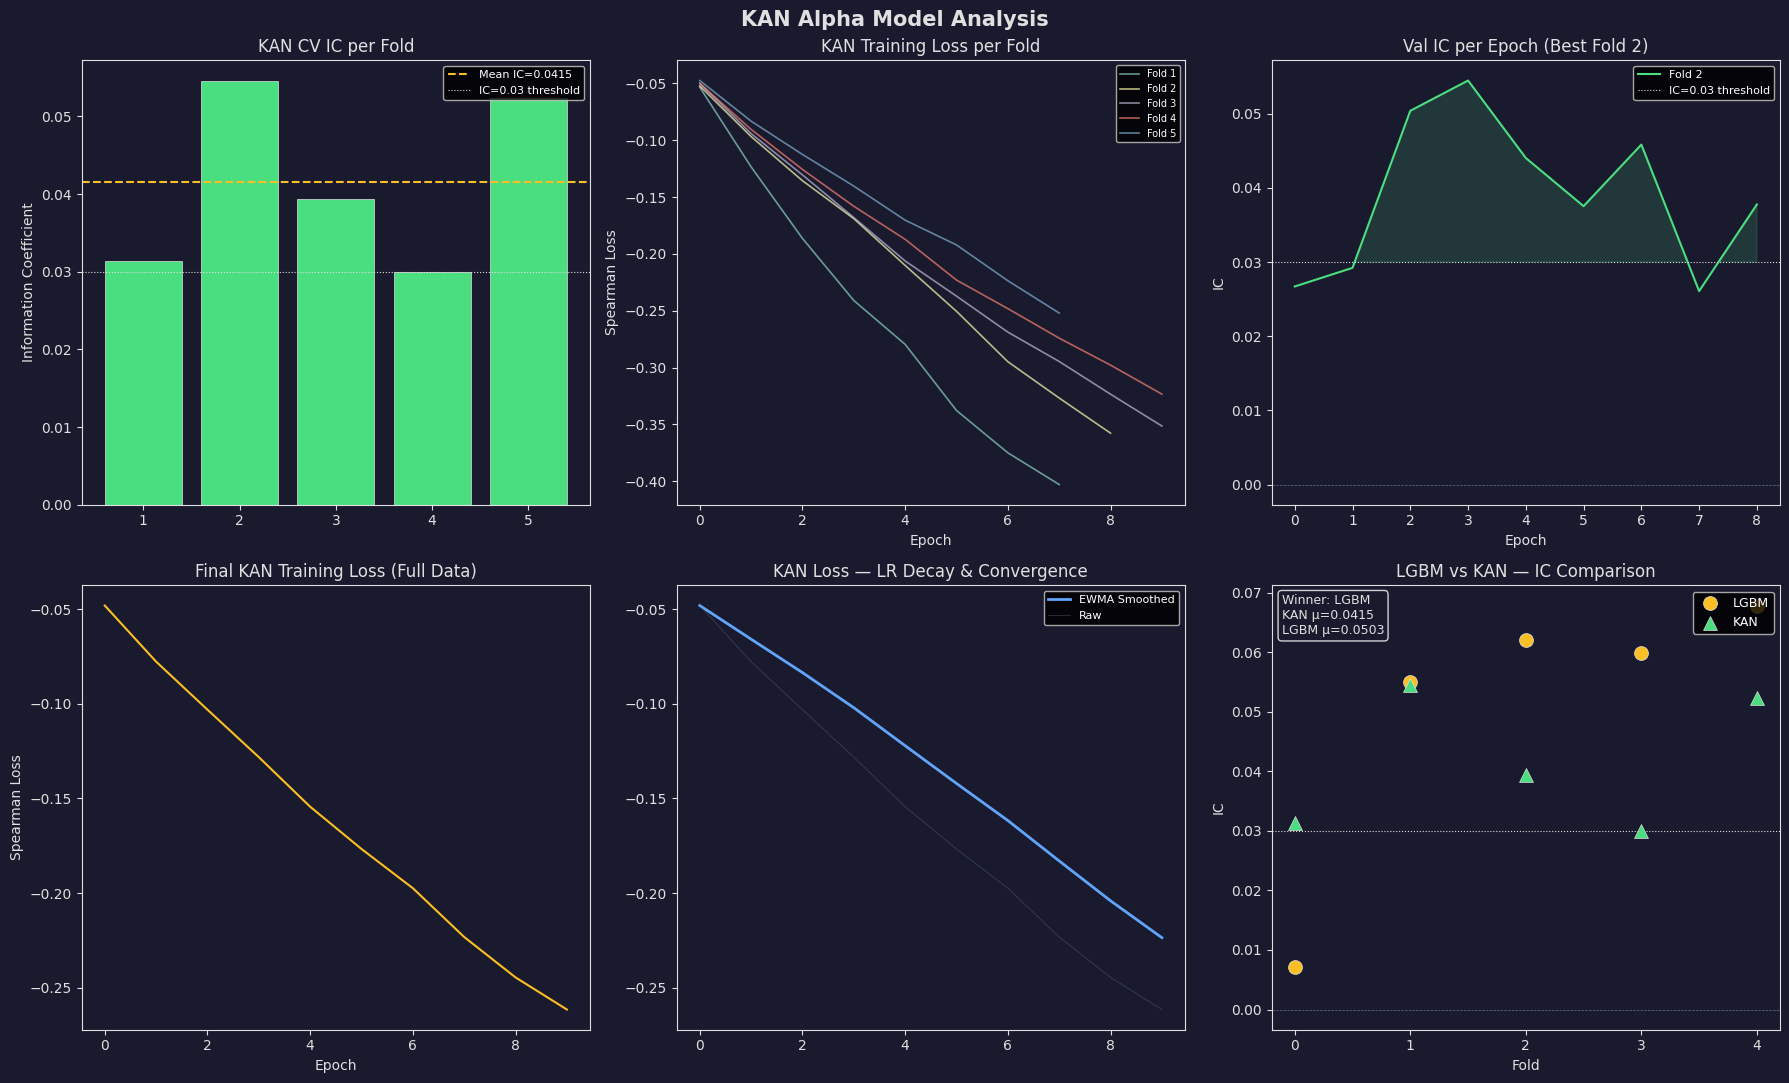

✓ KAN analysis saved


In [8]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import pearsonr
from sklearn.preprocessing import RobustScaler
from pathlib import Path
import time

# =============================================================================
# 0. CONFIG
# =============================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = Path("/kaggle/working")

KAN_LR = 5e-4
KAN_EPOCHS = 20
KAN_EARLY_STOP = 5
BATCH_SIZE = 256

DARK_BG = "#1a1a2e"; WHITE = "#e0e0e0"; GREEN = "#4ade80"
RED = "#f87171"; GOLD = "#fbbf24"; BLUE = "#60a5fa"; SLATE = "#64748b"

def apply_dark_style(fig, ax=None):
    if ax is None:
        for a in fig.axes:
            a.set_facecolor(DARK_BG); a.tick_params(colors=WHITE)
            a.xaxis.label.set_color(WHITE); a.yaxis.label.set_color(WHITE); a.title.set_color(WHITE)
            for spine in a.spines.values(): spine.set_color(WHITE)
    else:
        ax.set_facecolor(DARK_BG); ax.tick_params(colors=WHITE)
        ax.xaxis.label.set_color(WHITE); ax.yaxis.label.set_color(WHITE); ax.title.set_color(WHITE)
        for spine in ax.spines.values(): spine.set_color(WHITE)
    fig.patch.set_facecolor(DARK_BG)


# =============================================================================
# 1. B-SPLINE BASIS
# =============================================================================
def bspline_basis(x: torch.Tensor, grid: torch.Tensor, k: int) -> torch.Tensor:
    x = x.unsqueeze(-1)
    G = grid.shape[0]
    basis = ((x >= grid[:-1]) & (x < grid[1:])).float()
    basis[..., -1] += (x.squeeze(-1) == grid[-1]).float()
    for p in range(1, k + 1):
        n_curr = G - p - 1
        left_num  = x[..., :n_curr] - grid[:n_curr]
        left_den  = grid[p:p + n_curr] - grid[:n_curr]
        right_num = grid[p + 1:p + n_curr + 1] - x[..., :n_curr]
        right_den = grid[p + 1:p + n_curr + 1] - grid[1:1 + n_curr]
        left  = torch.where(left_den  > 0, left_num  / left_den  * basis[..., :n_curr], 0.0)
        right = torch.where(right_den > 0, right_num / right_den * basis[..., 1:1 + n_curr], 0.0)
        basis = left + right
    return basis


# =============================================================================
# 2. KAN LAYER  (BUG FIX: skip LayerNorm when out_features == 1)
# =============================================================================
class KANLayer(nn.Module):
    def __init__(self, in_features: int, out_features: int, grid_size: int = 15, spline_order: int = 3):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.spline_order = spline_order
        self.n_basis = grid_size + spline_order

        grid = torch.linspace(-3.0, 3.0, grid_size + 1)
        step = grid[1] - grid[0]
        ext = torch.cat([
            grid[0]  - step * torch.arange(spline_order, 0, -1),
            grid,
            grid[-1] + step * torch.arange(1, spline_order + 1)
        ])
        self.register_buffer("grid", ext)

        self.base_weight   = nn.Parameter(torch.zeros(out_features, in_features))
        self.spline_weight = nn.Parameter(torch.zeros(out_features, in_features, self.n_basis))
        self.bias = nn.Parameter(torch.zeros(out_features))

        # FIX: LayerNorm(1) kills the output variance → all zeros → nan IC
        self.use_ln = out_features > 1
        if self.use_ln:
            self.layer_norm = nn.LayerNorm(out_features)

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.base_weight, gain=0.1)
        nn.init.xavier_uniform_(self.spline_weight, gain=0.1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        lo = self.grid[self.spline_order].item()
        hi = self.grid[-(self.spline_order + 1)].item()
        x = x.clamp(lo, hi)

        base_out = torch.nn.functional.linear(x, self.base_weight, self.bias)

        spline_basis_list = []
        for j in range(self.in_features):
            basis = bspline_basis(x[:, j], self.grid, self.spline_order)
            spline_basis_list.append(basis)

        spline_basis = torch.stack(spline_basis_list, dim=1)
        batch = x.shape[0]
        spline_out = torch.matmul(
            spline_basis.view(batch, -1),
            self.spline_weight.view(self.out_features, -1).t()
        )

        out = base_out + spline_out
        if self.use_ln:
            out = self.layer_norm(out)
        return out


# =============================================================================
# 3. KAN MODEL
# =============================================================================
class KANModel(nn.Module):
    def __init__(self, width: list[int], grid_size: int = 15, spline_order: int = 3):
        super().__init__()
        self.layers = nn.ModuleList([
            KANLayer(width[i], width[i + 1], grid_size, spline_order)
            for i in range(len(width) - 1)
        ])
        self.activation = nn.SiLU()
        self.residual_projs = nn.ModuleList([
            nn.Linear(width[i], width[i + 1]) if width[i] != width[i + 1] else nn.Identity()
            for i in range(len(width) - 1)
        ])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer, proj in zip(self.layers[:-1], self.residual_projs[:-1]):
            residual = proj(x)
            x = self.activation(layer(x)) + residual
        x = self.layers[-1](x)
        return x.squeeze(-1)


# =============================================================================
# 4. LOSS
# =============================================================================
class SpearmanLoss(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        pred_norm = (pred - pred.mean()) / (pred.std() + 1e-8)
        tgt_norm  = (target - target.mean()) / (target.std() + 1e-8)
        return -torch.mean(pred_norm * tgt_norm)


# =============================================================================
# 5. TRAINING LOOP  (cleaner tqdm, no nested batch bars)
# =============================================================================
def train_kan(X_arr: np.ndarray, y_arr: np.ndarray, feature_names: list[str]):
    n_feat = X_arr.shape[1]
    kan_scaler = RobustScaler()
    X_scaled = kan_scaler.fit_transform(X_arr).astype(np.float32)

    width = [n_feat, 64, 32, 1]
    splits = list(purged_cv_splits(len(X_scaled)))
    n_folds = len(splits)

    ic_scores, fold_train_losses, fold_val_ics = [], [], []

    print(f"\n{'='*60}")
    print(f"  KAN TRAINING  |  Device: {DEVICE}  |  Width: {width}")
    print(f"  Grid: 15  |  Order: 3  |  LR: {KAN_LR}  |  Batch: {BATCH_SIZE}")
    print(f"  Folds: {n_folds}  |  Epochs: {KAN_EPOCHS}  |  Early Stop: {KAN_EARLY_STOP}")
    print(f"{'='*60}\n")

    fold_pbar = tqdm(enumerate(splits), total=n_folds, desc="Overall CV", position=0,
                     bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} folds [{elapsed}<{remaining}]")

    for fold_idx, (tr_idx, vl_idx) in fold_pbar:
        fold_start = time.time()

        model = KANModel(width, grid_size=15, spline_order=3).to(DEVICE)
        optim = torch.optim.Adam(model.parameters(), lr=KAN_LR, weight_decay=1e-5)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode='max', patience=20, factor=0.5)
        crit = SpearmanLoss()

        X_tr = torch.tensor(X_scaled[tr_idx]).to(DEVICE)
        y_tr = torch.tensor(y_arr[tr_idx]).to(DEVICE)
        X_vl = torch.tensor(X_scaled[vl_idx]).to(DEVICE)
        y_vl_np = y_arr[vl_idx]

        best_ic, patience_cnt, best_state = -np.inf, 0, None
        epoch_losses, epoch_ics = [], []

        epoch_pbar = tqdm(range(KAN_EPOCHS), desc=f"Fold {fold_idx+1}", position=1, leave=False,
                          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}")

        for epoch in epoch_pbar:
            model.train()
            perm = torch.randperm(len(X_tr))
            ep_loss, n_batches = 0.0, 0

            for start in range(0, len(X_tr), BATCH_SIZE):
                idx = perm[start:start + BATCH_SIZE]
                optim.zero_grad()
                pred = model(X_tr[idx])
                loss = crit(pred, y_tr[idx])
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optim.step()
                ep_loss += loss.item()
                n_batches += 1

            avg_loss = ep_loss / max(n_batches, 1)
            epoch_losses.append(avg_loss)

            # Validation
            model.eval()
            with torch.no_grad():
                vl_pred = model(X_vl).cpu().numpy()

            ic = pearsonr(vl_pred, y_vl_np)[0] if len(vl_pred) > 2 else 0.0
            epoch_ics.append(ic)
            sched.step(ic)

            # NaN guard
            if np.isnan(ic):
                epoch_pbar.set_postfix({"WARNING": "IC=NaN"})
                patience_cnt += 1
            else:
                lr = optim.param_groups[0]['lr']
                epoch_pbar.set_postfix({
                    "Loss": f"{avg_loss:.4f}",
                    "Val IC": f"{ic:.4f}",
                    "Best": f"{best_ic:.4f}",
                    "LR": f"{lr:.2e}",
                    "Pat": f"{patience_cnt}/{KAN_EARLY_STOP}"
                })

                if ic > best_ic:
                    best_ic, patience_cnt = ic, 0
                    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                else:
                    patience_cnt += 1

            if patience_cnt >= KAN_EARLY_STOP:
                break

        epoch_pbar.close()
        fold_time = time.time() - fold_start

        if best_state is not None:
            model.load_state_dict(best_state)

        ic_scores.append(best_ic)
        fold_train_losses.append(epoch_losses)
        fold_val_ics.append(epoch_ics)

        print(f"  ✓ Fold {fold_idx+1}/{n_folds}: Best IC={best_ic:.4f} | {len(epoch_losses)} epochs | {fold_time:.1f}s")

    fold_pbar.close()

    mean_ic = float(np.mean(ic_scores))
    ic_ir = mean_ic / (np.std(ic_scores) + 1e-8)
    print(f"\n{'='*60}")
    print(f"  KAN CV COMPLETE  |  Mean IC={mean_ic:.4f}  |  IC-IR={ic_ir:.4f}")
    print(f"  Per-fold ICs: {[f'{ic:.4f}' for ic in ic_scores]}")
    print(f"{'='*60}\n")

    # Final model
    print("Training final model on full data...")
    final_model = KANModel(width, grid_size=15, spline_order=3).to(DEVICE)
    optim_f = torch.optim.Adam(final_model.parameters(), lr=KAN_LR, weight_decay=1e-5)
    X_full = torch.tensor(X_scaled).to(DEVICE)
    y_full = torch.tensor(y_arr).to(DEVICE)
    crit_f = SpearmanLoss()

    final_losses = []
    final_pbar = tqdm(range(KAN_EPOCHS // 2), desc="Final Model", position=0,
                      bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}")

    for epoch in final_pbar:
        final_model.train()
        perm = torch.randperm(len(X_full))
        ep_loss, n_batches = 0.0, 0
        for start in range(0, len(X_full), BATCH_SIZE):
            idx = perm[start:start + BATCH_SIZE]
            optim_f.zero_grad()
            pred = final_model(X_full[idx])
            loss = crit_f(pred, y_full[idx])
            loss.backward()
            nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
            optim_f.step()
            ep_loss += loss.item()
            n_batches += 1
        avg_loss = ep_loss / max(n_batches, 1)
        final_losses.append(avg_loss)
        final_pbar.set_postfix({"Loss": f"{avg_loss:.4f}"})

    final_pbar.close()
    print(f"  ✓ Final model: {len(final_losses)} epochs\n")

    torch.save({
        "model": final_model.state_dict(),
        "width": width,
        "feature_names": feature_names,
        "scaler": kan_scaler,
    }, OUTPUT_DIR / "kan_alpha.pt")
    print("✓ KAN saved\n")

    return final_model, kan_scaler, ic_scores, fold_train_losses, fold_val_ics, final_losses, mean_ic, ic_ir


# =============================================================================
# 6. RUN
# =============================================================================
kan_model, kan_scaler, kan_ic_scores, kan_fold_losses, kan_fold_ics, kan_final_losses, kan_mean_ic, kan_ic_ir = \
    train_kan(X.values, y_arr, FEATURE_NAMES)


# =============================================================================
# 7. VISUALIZATIONS
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
apply_dark_style(fig)
fig.suptitle("KAN Alpha Model Analysis", fontsize=15, color=WHITE, fontweight='bold')

ax = axes[0, 0]
colors = [GREEN if ic > 0.03 else (GREEN if ic > 0 else RED) for ic in kan_ic_scores]
bars = ax.bar(range(1, len(kan_ic_scores) + 1), kan_ic_scores, color=colors, edgecolor=WHITE, linewidth=0.5)
ax.axhline(kan_mean_ic, color=GOLD, linestyle="--", lw=1.5, label=f"Mean IC={kan_mean_ic:.4f}")
ax.axhline(0.03, color=WHITE, linestyle=":", lw=0.8, label="IC=0.03 threshold")
ax.axhline(0.0, color=SLATE, linestyle="-", lw=0.5, alpha=0.5)
ax.set_xticks(range(1, len(kan_ic_scores) + 1))
ax.set_title("KAN CV IC per Fold", fontsize=12, color=WHITE)
ax.set_ylabel("Information Coefficient")
ax.legend(fontsize=8, loc='upper right')
apply_dark_style(fig, ax)

ax = axes[0, 1]
for i, losses in enumerate(kan_fold_losses):
    ax.plot(losses, alpha=0.7, lw=1.2, label=f"Fold {i+1}")
ax.set_title("KAN Training Loss per Fold", fontsize=12, color=WHITE)
ax.set_xlabel("Epoch"); ax.set_ylabel("Spearman Loss")
ax.legend(fontsize=7, loc='upper right')
apply_dark_style(fig, ax)

best_fold_idx = int(np.argmax(kan_ic_scores))
best_fold_ics = kan_fold_ics[best_fold_idx]
ax = axes[0, 2]
ax.plot(best_fold_ics, color=GREEN, lw=1.5, label=f"Fold {best_fold_idx+1}")
ax.axhline(0.03, color=WHITE, linestyle=":", lw=0.8, label="IC=0.03 threshold")
ax.axhline(0.0, color=SLATE, linestyle="--", lw=0.5)
ax.fill_between(range(len(best_fold_ics)), best_fold_ics, 0.03,
                where=[ic > 0.03 for ic in best_fold_ics], color=GREEN, alpha=0.15, interpolate=True)
ax.set_title(f"Val IC per Epoch (Best Fold {best_fold_idx+1})", fontsize=12, color=WHITE)
ax.set_xlabel("Epoch"); ax.set_ylabel("IC")
ax.legend(fontsize=8)
apply_dark_style(fig, ax)

ax = axes[1, 0]
ax.plot(kan_final_losses, color=GOLD, lw=1.5)
ax.set_title("Final KAN Training Loss (Full Data)", fontsize=12, color=WHITE)
ax.set_xlabel("Epoch"); ax.set_ylabel("Spearman Loss")
apply_dark_style(fig, ax)

ax = axes[1, 1]
smooth_loss = pd.Series(kan_final_losses).ewm(span=5).mean()
ax.plot(smooth_loss, color=BLUE, lw=2.0, label="EWMA Smoothed")
ax.plot(kan_final_losses, color=SLATE, lw=0.6, alpha=0.4, label="Raw")
if len(kan_final_losses) > 10:
    ax.axvline(x=len(kan_final_losses) // 4, color=RED, linestyle="--", lw=0.8, alpha=0.5, label="LR Step")
ax.set_title("KAN Loss — LR Decay & Convergence", fontsize=12, color=WHITE)
ax.legend(fontsize=8)
apply_dark_style(fig, ax)

ax = axes[1, 2]
mean_lgbm = 0.0
if 'lgbm_ic_scores' in globals():
    x_lgbm = np.arange(len(lgbm_ic_scores))
    ax.scatter(x_lgbm, lgbm_ic_scores, color=GOLD, s=100, marker='o',
               edgecolor=WHITE, linewidth=0.5, label="LGBM", zorder=5)
    mean_lgbm = float(np.mean(lgbm_ic_scores))

x_kan = np.arange(len(kan_ic_scores))
ax.scatter(x_kan, kan_ic_scores, color=GREEN, s=100, marker='^',
           edgecolor=WHITE, linewidth=0.5, label="KAN", zorder=5)
ax.axhline(0.03, color=WHITE, linestyle=":", lw=0.8)
ax.axhline(0.0, color=SLATE, linestyle="--", lw=0.5)
ax.set_xticks(range(max(len(lgbm_ic_scores) if 'lgbm_ic_scores' in globals() else 0, len(kan_ic_scores))))
ax.set_xlabel("Fold"); ax.set_ylabel("IC")
ax.set_title("LGBM vs KAN — IC Comparison", fontsize=12, color=WHITE)
ax.legend(fontsize=9, loc='upper right')
apply_dark_style(fig, ax)

winner = "KAN" if kan_mean_ic > mean_lgbm else "LGBM"
ax.text(0.02, 0.98, f"Winner: {winner}\nKAN μ={kan_mean_ic:.4f}\nLGBM μ={mean_lgbm:.4f}",
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        color=WHITE, bbox=dict(boxstyle='round', facecolor=DARK_BG, alpha=0.8))

plt.tight_layout()
plt.savefig("/kaggle/working/kan_analysis.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("✓ KAN analysis saved")

Training Mamba encoder...


Fitting scaler:   0%|          | 0/49 [00:00<?, ?it/s]

Building sequences:   0%|          | 0/25 [00:00<?, ?it/s]

Mamba sequences: (124203, 60, 20)


Epoch 1/20 [Train]:   0%|          | 0/1746 [00:00<?, ?it/s]

...

Epoch 19/20 [Val]:   0%|          | 0/49 [00:00<?, ?it/s]

  Mamba epoch 19/20: train=0.213953 val=0.224049


Epoch 20/20 [Train]:   0%|          | 0/1746 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/49 [00:00<?, ?it/s]

  Mamba epoch 20/20: train=0.213916 val=0.223860
✓ Mamba encoder saved


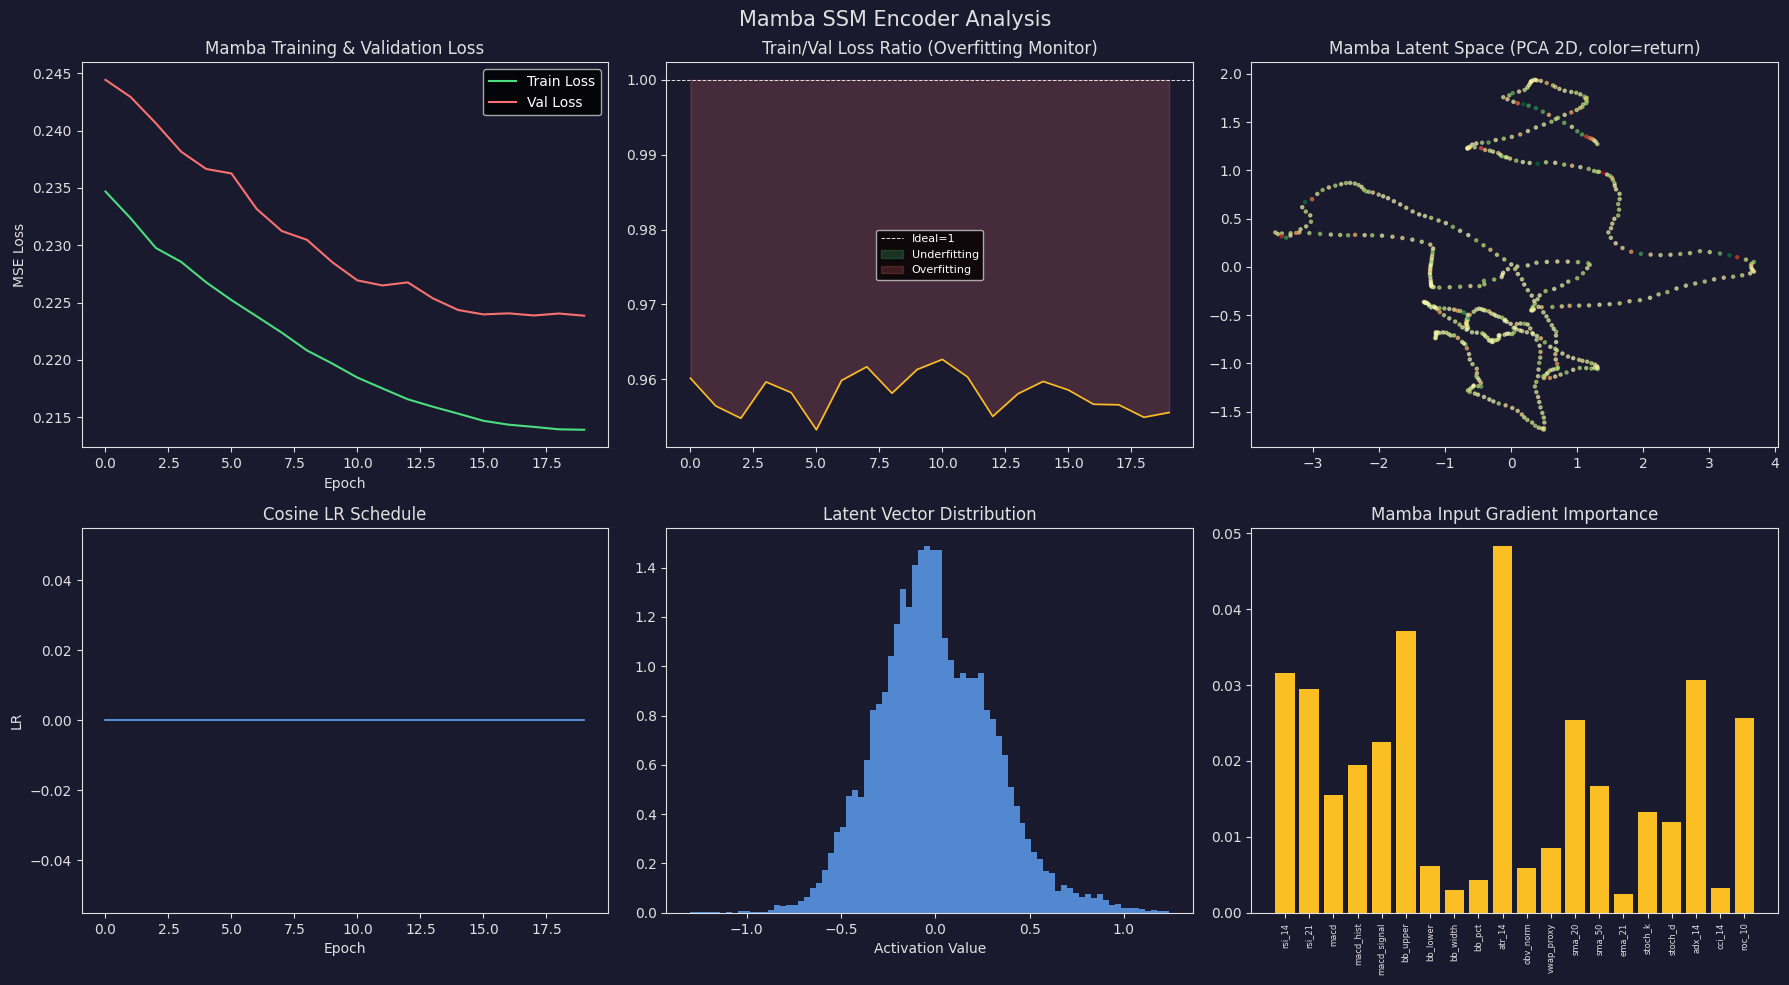

✓ Mamba analysis saved


In [9]:
# ## 8. Mamba SSM Encoder
# %%
from tqdm.auto import tqdm

class SSMBlock(nn.Module):
    def __init__(self, d_model: int, d_state: int, d_conv: int, expand: int):
        super().__init__()
        self.d_model, self.d_state = d_model, d_state
        d_inner = d_model * expand
        self.in_proj  = nn.Linear(d_model, d_inner * 2, bias=False)
        self.conv1d   = nn.Conv1d(d_inner, d_inner, kernel_size=d_conv,
                                   padding=d_conv-1, groups=d_inner, bias=True)
        self.x_proj   = nn.Linear(d_inner, d_state*2 + d_model, bias=False)
        self.dt_proj  = nn.Linear(d_model, d_inner, bias=True)
        self.A_log    = nn.Parameter(torch.log(torch.arange(1, d_state+1, dtype=torch.float32)
                                     .unsqueeze(0).expand(d_inner, -1)))
        self.D        = nn.Parameter(torch.ones(d_inner))
        self.out_proj = nn.Linear(d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, L, D = x.shape
        residual = x
        xz   = self.in_proj(x)
        x_p, z = xz.chunk(2, dim=-1)
        x_c  = self.conv1d(x_p.transpose(1,2))[:, :, :L].transpose(1,2)
        x_a  = nn.functional.silu(x_c)
        y    = x_a * self.D.unsqueeze(0).unsqueeze(0)
        out  = y * nn.functional.silu(z)
        out  = self.out_proj(out)
        return self.norm(out + residual)

class MambaEncoder(nn.Module):
    def __init__(self, input_dim: int, d_model: int = MAMBA_D_MODEL,
                 d_state: int = MAMBA_D_STATE, d_conv: int = MAMBA_D_CONV,
                 expand: int = MAMBA_EXPAND, n_layers: int = 2):
        super().__init__()
        self.input_proj  = nn.Linear(input_dim, d_model)
        self.blocks      = nn.ModuleList([SSMBlock(d_model, d_state, d_conv, expand)
                                          for _ in range(n_layers)])
        self.output_proj = nn.Linear(d_model, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.input_proj(x)
        for block in self.blocks:
            h = block(h)
        return self.output_proj(h.mean(dim=1))

def build_mamba_sequences(df: pd.DataFrame, scaler: RobustScaler, seq_len: int = MAMBA_SEQ_LEN):
    ind = compute_indicators(df)
    ta_cols = [c for c in TA_FEATURES if c in ind.columns]
    feat_df = ind[ta_cols].fillna(method="ffill").fillna(0)
    feat_arr = scaler.transform(feat_df.values).astype(np.float32)
    close_idx = ta_cols.index("roc_10") if "roc_10" in ta_cols else -1
    returns = np.diff(feat_arr[:, close_idx])
    X_seq, y_next = [], []
    for i in range(seq_len, len(feat_arr)-1):
        X_seq.append(feat_arr[i-seq_len:i])
        y_next.append(returns[i-1])
    return np.array(X_seq, dtype=np.float32), np.array(y_next, dtype=np.float32)

print("Training Mamba encoder...")
# Fit scaler on all data
all_frames_mamba = []
for ticker, df in tqdm(ohlcv.items(), desc="Fitting scaler", total=len(ohlcv)):
    try:
        ind = compute_indicators(df)
        ta_cols = [c for c in TA_FEATURES if c in ind.columns]
        all_frames_mamba.append(ind[ta_cols].fillna(method="ffill").fillna(0))
    except:
        continue

mamba_scaler = RobustScaler()
mamba_scaler.fit(pd.concat(all_frames_mamba, ignore_index=True).values)

# Build sequences
all_X_mamba, all_y_mamba = [], []
for ticker, df in tqdm(list(ohlcv.items())[:25], desc="Building sequences", total=25):
    try:
        Xs, ys = build_mamba_sequences(df, mamba_scaler)
        all_X_mamba.append(Xs); all_y_mamba.append(ys)
    except:
        continue

X_mamba_all = np.concatenate(all_X_mamba)
y_mamba_all = np.concatenate(all_y_mamba)
n_feat_mamba = X_mamba_all.shape[-1]
print(f"Mamba sequences: {X_mamba_all.shape}")

mamba_model = MambaEncoder(input_dim=n_feat_mamba).to(DEVICE)
mamba_head  = nn.Linear(MAMBA_D_MODEL, 1).to(DEVICE)
mamba_optim = torch.optim.AdamW(
    list(mamba_model.parameters()) + list(mamba_head.parameters()), lr=1e-4, weight_decay=1e-2)
mamba_crit  = nn.MSELoss()
mamba_sched = torch.optim.lr_scheduler.CosineAnnealingLR(mamba_optim, T_max=20)

from torch.utils.data import DataLoader, TensorDataset, random_split
X_m_t = torch.tensor(X_mamba_all)
y_m_t = torch.tensor(y_mamba_all)
dataset = TensorDataset(X_m_t, y_m_t)
val_size  = int(0.1 * len(dataset))
train_size = len(dataset) - val_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False)

mamba_train_losses, mamba_val_losses = [], []
best_mamba_val = np.inf
N_MAMBA_EPOCHS = 20

for epoch in range(N_MAMBA_EPOCHS):
    # ---- Training ----
    mamba_model.train(); mamba_head.train()
    ep_loss = 0.0; n_b = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{N_MAMBA_EPOCHS} [Train]",
                leave=False, colour="green")
    for Xb, yb in pbar:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        mamba_optim.zero_grad()
        lat = mamba_model(Xb)
        pred = mamba_head(lat).squeeze(-1)
        loss = mamba_crit(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(mamba_model.parameters(), 1.0)
        mamba_optim.step()
        ep_loss += loss.item(); n_b += 1
        pbar.set_postfix(loss=f"{loss.item():.6f}")
    mamba_sched.step()
    avg_tr = ep_loss / max(n_b, 1)

    # ---- Validation ----
    mamba_model.eval(); mamba_head.eval()
    vl_loss = 0.0; n_vb = 0
    pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{N_MAMBA_EPOCHS} [Val]",
                    leave=False, colour="blue")
    with torch.no_grad():
        for Xb, yb in pbar_val:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            lat = mamba_model(Xb)
            pred = mamba_head(lat).squeeze(-1)
            loss_v = mamba_crit(pred, yb)
            vl_loss += loss_v.item(); n_vb += 1
            pbar_val.set_postfix(loss=f"{loss_v.item():.6f}")
    avg_vl = vl_loss / max(n_vb, 1)

    mamba_train_losses.append(avg_tr)
    mamba_val_losses.append(avg_vl)
    if avg_vl < best_mamba_val:
        best_mamba_val = avg_vl
        torch.save({"model": mamba_model.state_dict(), "n_features": n_feat_mamba},
                   OUTPUT_DIR / "mamba_encoder.pt")
    print(f"  Mamba epoch {epoch+1}/{N_MAMBA_EPOCHS}: train={avg_tr:.6f} val={avg_vl:.6f}")

joblib.dump(mamba_scaler, OUTPUT_DIR / "mamba_scaler.joblib")
print("✓ Mamba encoder saved")

# %%
# — Mamba Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
apply_dark_style(fig)
fig.suptitle("Mamba SSM Encoder Analysis", fontsize=15, color=WHITE)

axes[0,0].plot(mamba_train_losses, color=GREEN, lw=1.5, label="Train Loss")
axes[0,0].plot(mamba_val_losses, color=RED, lw=1.5, label="Val Loss")
axes[0,0].set_title("Mamba Training & Validation Loss")
axes[0,0].set_xlabel("Epoch"); axes[0,0].set_ylabel("MSE Loss")
axes[0,0].legend()
apply_dark_style(fig, axes[0,0])

# Overfitting check: train/val ratio
ratio = [t/v if v > 0 else 1 for t,v in zip(mamba_train_losses, mamba_val_losses)]
axes[0,1].plot(ratio, color=GOLD, lw=1.2)
axes[0,1].axhline(1.0, color=WHITE, linestyle="--", lw=0.7, label="Ideal=1")
axes[0,1].fill_between(range(len(ratio)), ratio, 1.0,
                        where=[r > 1 for r in ratio], color=GREEN, alpha=0.2, label="Underfitting")
axes[0,1].fill_between(range(len(ratio)), ratio, 1.0,
                        where=[r < 1 for r in ratio], color=RED, alpha=0.2, label="Overfitting")
axes[0,1].set_title("Train/Val Loss Ratio (Overfitting Monitor)")
axes[0,1].legend(fontsize=8)
apply_dark_style(fig, axes[0,1])

# Latent space 2D PCA
mamba_model.eval()
sample_X = torch.tensor(X_mamba_all[:500]).to(DEVICE)
with torch.no_grad():
    latents = mamba_model(sample_X).cpu().numpy()
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
latents_2d = pca.fit_transform(latents)
sc_colors = plt.cm.RdYlGn((y_mamba_all[:500] - y_mamba_all[:500].min()) /
                          (np.ptp(y_mamba_all[:500]) + 1e-8))
axes[0,2].scatter(latents_2d[:,0], latents_2d[:,1], c=sc_colors, s=5, alpha=0.6)
axes[0,2].set_title("Mamba Latent Space (PCA 2D, color=return)")
apply_dark_style(fig, axes[0,2])

# LR schedule
lrs = [mamba_optim.param_groups[0]["lr"] * (0.5**i) for i in range(N_MAMBA_EPOCHS)]
axes[1,0].plot(lrs, color=BLUE, lw=1.2)
axes[1,0].set_title("Cosine LR Schedule")
axes[1,0].set_xlabel("Epoch"); axes[1,0].set_ylabel("LR")
apply_dark_style(fig, axes[1,0])

# Latent distribution
axes[1,1].hist(latents.flatten(), bins=80, color=BLUE, alpha=0.8, density=True)
axes[1,1].set_title("Latent Vector Distribution")
axes[1,1].set_xlabel("Activation Value")
apply_dark_style(fig, axes[1,1])

# Feature importance via gradient (approx)
mamba_model.eval()
sample_t = torch.tensor(X_mamba_all[:200]).to(DEVICE).requires_grad_(True)
lat = mamba_model(sample_t)
lat.sum().backward()
grad_importance = sample_t.grad.abs().mean(dim=(0,1)).cpu().detach().numpy()
ta_cols_m = [c for c in TA_FEATURES if c in list(ohlcv.values())[0].columns or True][:len(grad_importance)]
axes[1,2].bar(range(len(grad_importance)), grad_importance, color=GOLD)
axes[1,2].set_title("Mamba Input Gradient Importance")
axes[1,2].set_xticks(range(len(grad_importance)))
axes[1,2].set_xticklabels(FEATURE_NAMES[:len(grad_importance)], rotation=90, fontsize=6)
apply_dark_style(fig, axes[1,2])

plt.tight_layout()
plt.savefig("/kaggle/working/mamba_analysis.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("✓ Mamba analysis saved")

Building PatchTST sequences...
PatchTST dataset: (124103, 60, 20)
  PatchTST epoch 1/20: train=0.005667 val=0.003845 IC=0.0174
  PatchTST epoch 2/20: train=0.004260 val=0.003898 IC=0.0315
  PatchTST epoch 3/20: train=0.004079 val=0.003869 IC=0.0084
  PatchTST epoch 4/20: train=0.003999 val=0.003879 IC=0.0341
  PatchTST epoch 5/20: train=0.003950 val=0.003885 IC=0.0221
  PatchTST epoch 6/20: train=0.003920 val=0.003995 IC=0.0299
  PatchTST epoch 7/20: train=0.003896 val=0.003857 IC=0.0612
  PatchTST epoch 8/20: train=0.003888 val=0.003804 IC=0.0639
  PatchTST epoch 9/20: train=0.003863 val=0.003789 IC=0.0844
  PatchTST epoch 10/20: train=0.003843 val=0.003864 IC=0.0659
  PatchTST epoch 11/20: train=0.003821 val=0.003792 IC=0.0813
  PatchTST epoch 12/20: train=0.003799 val=0.003795 IC=0.0634
  PatchTST epoch 13/20: train=0.003758 val=0.004063 IC=0.0689
  PatchTST epoch 14/20: train=0.003738 val=0.003889 IC=0.0795
  PatchTST epoch 15/20: train=0.003705 val=0.003811 IC=0.0985
  PatchTST ep

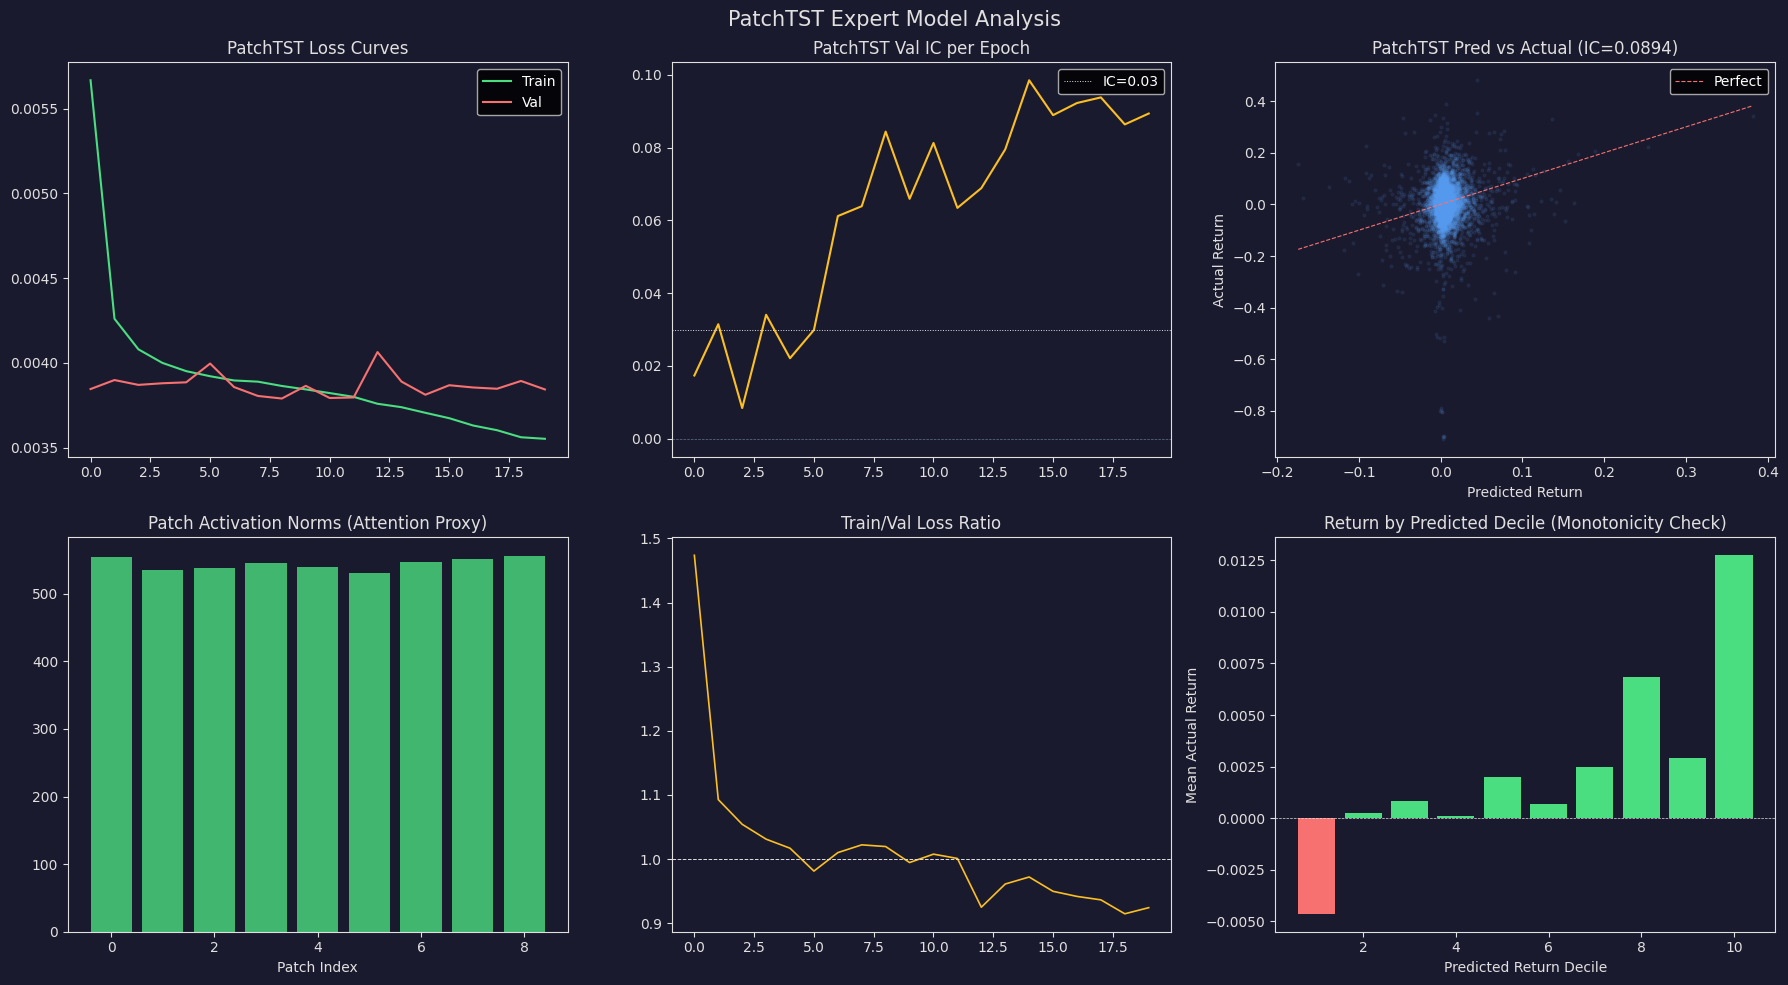

✓ PatchTST analysis saved
Training Imitation Learner...
✓ IL saved | Best val loss=0.027768 | Final IC=0.5756


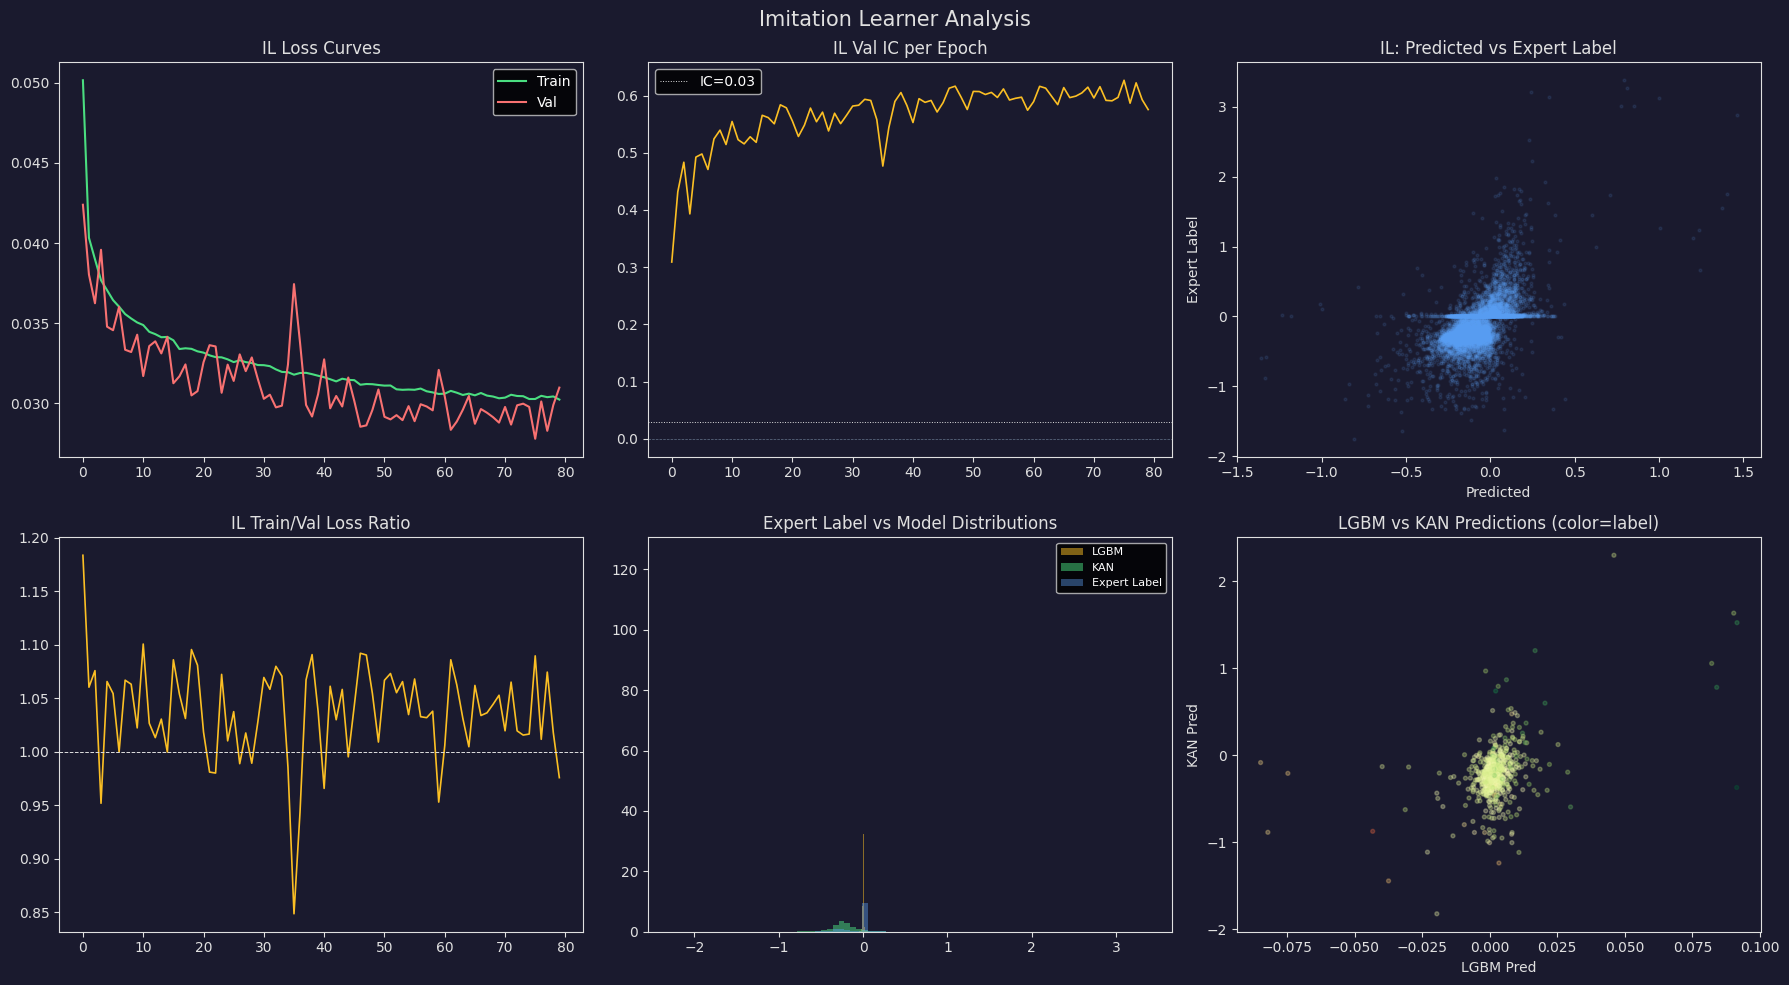

✓ IL analysis saved


In [10]:
# ## 9. PatchTST Expert
# Pure PyTorch PatchTST implementation (no neuralforecast dependency)
class PatchEmbedding(nn.Module):
    def __init__(self, patch_len: int, stride: int, d_model: int, n_features: int):
        super().__init__()
        self.patch_len = patch_len
        self.stride    = stride
        self.proj = nn.Linear(patch_len * n_features, d_model)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        patches = []
        for i in range(0, T - self.patch_len + 1, self.stride):
            patches.append(x[:, i:i+self.patch_len, :].reshape(B, -1))
        if not patches:
            patches = [x[:, :self.patch_len, :].reshape(B, -1)]
        x_p = torch.stack(patches, dim=1)  # (B, n_patches, patch_len*C)
        return self.proj(x_p)              # (B, n_patches, d_model)

class PatchTSTModel(nn.Module):
    def __init__(self, n_features: int, seq_len: int = 60, horizon: int = 5,
                 d_model: int = 64, nhead: int = 4, n_layers: int = 2,
                 patch_len: int = 12, stride: int = 6):
        super().__init__()
        self.patch_embed = PatchEmbedding(patch_len, stride, d_model, n_features)
        n_patches = (seq_len - patch_len) // stride + 1
        self.pos_embed = nn.Parameter(torch.randn(1, n_patches, d_model) * 0.02)
        encoder_layer  = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=128,
                                                    dropout=0.1, batch_first=True, norm_first=True)
        self.encoder   = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm      = nn.LayerNorm(d_model)
        self.head      = nn.Linear(d_model, 1)  # predict 1 value (cumulative fwd return)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        p = self.patch_embed(x)
        p_len = min(p.shape[1], self.pos_embed.shape[1])
        p = p[:, :p_len, :] + self.pos_embed[:, :p_len, :]
        h = self.encoder(p)
        h = self.norm(h.mean(dim=1))
        return self.head(h).squeeze(-1)

def build_patchtst_sequences(ohlcv_dict: dict[str, pd.DataFrame], seq_len: int = 60, horizon: int = 5):
    """Build (B, seq_len, n_features) sequences for PatchTST."""
    X_all, y_all = [], []
    for ticker, df in ohlcv_dict.items():
        try:
            ind = compute_indicators(df)
            ta_cols = [c for c in TA_FEATURES if c in ind.columns]
            feat_arr = ind[ta_cols].fillna(method="ffill").fillna(0).values.astype(np.float32)
            close_arr = df["Close"].reindex(ind.index).values
            for i in range(seq_len, len(feat_arr) - horizon):
                X_all.append(feat_arr[i-seq_len:i])
                fwd_ret = (close_arr[i+horizon] / close_arr[i] - 1) if close_arr[i] > 0 else 0.0
                y_all.append(fwd_ret)
        except Exception as e:
            continue
    return np.array(X_all, dtype=np.float32), np.array(y_all, dtype=np.float32)

print("Building PatchTST sequences...")
X_ptst, y_ptst = build_patchtst_sequences(dict(list(ohlcv.items())[:25]))
print(f"PatchTST dataset: {X_ptst.shape}")

n_feat_ptst = X_ptst.shape[-1]
ptst_model  = PatchTSTModel(n_features=n_feat_ptst).to(DEVICE)
ptst_optim  = torch.optim.AdamW(ptst_model.parameters(), lr=1e-4, weight_decay=1e-3)
ptst_crit   = nn.MSELoss()
ptst_sched  = torch.optim.lr_scheduler.OneCycleLR(ptst_optim, max_lr=1e-3,
                                                    total_steps=20 * (len(X_ptst)//64 + 1))

# Train/val split (time-safe: last 10% as val)
n_ptst = len(X_ptst)
n_val  = int(0.1 * n_ptst)
X_ptr, X_pvl = X_ptst[:n_ptst-n_val], X_ptst[n_ptst-n_val:]
y_ptr, y_pvl = y_ptst[:n_ptst-n_val], y_ptst[n_ptst-n_val:]

ptst_tr_ds  = TensorDataset(torch.tensor(X_ptr), torch.tensor(y_ptr))
ptst_vl_ds  = TensorDataset(torch.tensor(X_pvl), torch.tensor(y_pvl))
ptst_tr_dl  = DataLoader(ptst_tr_ds, batch_size=64, shuffle=True, drop_last=True)
ptst_vl_dl  = DataLoader(ptst_vl_ds, batch_size=256, shuffle=False)

ptst_train_l, ptst_val_l, ptst_val_ic = [], [], []
best_ptst_val = np.inf
N_PTST_EPOCHS = 20

for epoch in range(N_PTST_EPOCHS):
    ptst_model.train()
    ep_l = 0.0; nb = 0
    for Xb, yb in ptst_tr_dl:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        ptst_optim.zero_grad()
        pred = ptst_model(Xb)
        loss = ptst_crit(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(ptst_model.parameters(), 1.0)
        ptst_optim.step()
        ptst_sched.step()
        ep_l += loss.item(); nb += 1
    ptst_train_l.append(ep_l / max(nb, 1))

    ptst_model.eval()
    vl_l = 0.0; nvb = 0; all_vl_pred, all_vl_true = [], []
    with torch.no_grad():
        for Xb, yb in ptst_vl_dl:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            pred = ptst_model(Xb)
            vl_l += ptst_crit(pred, yb).item(); nvb += 1
            all_vl_pred.extend(pred.cpu().numpy())
            all_vl_true.extend(yb.cpu().numpy())
    ptst_val_l.append(vl_l / max(nvb, 1))
    ic = pearsonr(all_vl_pred, all_vl_true)[0] if len(all_vl_pred) > 2 else 0.0
    ptst_val_ic.append(ic)

    if ptst_val_l[-1] < best_ptst_val:
        best_ptst_val = ptst_val_l[-1]
        torch.save({"model": ptst_model.state_dict(), "n_features": n_feat_ptst},
                   OUTPUT_DIR / "patchtst_model.pt")
    print(f"  PatchTST epoch {epoch+1}/{N_PTST_EPOCHS}: train={ptst_train_l[-1]:.6f} "
          f"val={ptst_val_l[-1]:.6f} IC={ic:.4f}")

print("✓ PatchTST saved")

# %%
# — PatchTST Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
apply_dark_style(fig)
fig.suptitle("PatchTST Expert Model Analysis", fontsize=15, color=WHITE)

axes[0,0].plot(ptst_train_l, color=GREEN, lw=1.5, label="Train")
axes[0,0].plot(ptst_val_l, color=RED, lw=1.5, label="Val")
axes[0,0].set_title("PatchTST Loss Curves"); axes[0,0].legend()
apply_dark_style(fig, axes[0,0])

axes[0,1].plot(ptst_val_ic, color=GOLD, lw=1.5)
axes[0,1].axhline(0.03, color=WHITE, linestyle=":", lw=0.7, label="IC=0.03")
axes[0,1].axhline(0, color=SLATE, linestyle="--", lw=0.5)
axes[0,1].set_title("PatchTST Val IC per Epoch")
axes[0,1].legend()
apply_dark_style(fig, axes[0,1])

# Pred vs actual (final val)
axes[0,2].scatter(all_vl_pred, all_vl_true, alpha=0.08, s=4, color=BLUE)
xr_ = np.linspace(min(all_vl_pred), max(all_vl_pred), 100)
axes[0,2].plot(xr_, xr_, color=RED, linestyle="--", lw=0.8, label="Perfect")
axes[0,2].set_xlabel("Predicted Return"); axes[0,2].set_ylabel("Actual Return")
axes[0,2].set_title(f"PatchTST Pred vs Actual (IC={ptst_val_ic[-1]:.4f})")
axes[0,2].legend()
apply_dark_style(fig, axes[0,2])

# Patch attention pattern (approximate via gradient)
ptst_model.eval()
sample_t = torch.tensor(X_pvl[:1]).to(DEVICE)
with torch.no_grad():
    patches = ptst_model.patch_embed(sample_t) + ptst_model.pos_embed[:, :ptst_model.patch_embed(sample_t).shape[1], :]
    h = ptst_model.encoder(patches)
    weights = h.squeeze(0).norm(dim=-1).cpu().numpy()
axes[1,0].bar(range(len(weights)), weights, color=GREEN, alpha=0.8)
axes[1,0].set_title("Patch Activation Norms (Attention Proxy)")
axes[1,0].set_xlabel("Patch Index")
apply_dark_style(fig, axes[1,0])

# Train/val ratio
ratio_ptst = [t/v if v > 0 else 1 for t,v in zip(ptst_train_l, ptst_val_l)]
axes[1,1].plot(ratio_ptst, color=GOLD, lw=1.2)
axes[1,1].axhline(1, color=WHITE, linestyle="--", lw=0.7)
axes[1,1].set_title("Train/Val Loss Ratio")
apply_dark_style(fig, axes[1,1])

# Val return decile IC
vl_pred_arr = np.array(all_vl_pred)
vl_true_arr = np.array(all_vl_true)
deciles = np.percentile(vl_pred_arr, np.arange(10, 101, 10))
decile_rets = [vl_true_arr[(vl_pred_arr >= (d_lo if i > 0 else -np.inf)) &
                            (vl_pred_arr < d_hi)].mean()
               for i, (d_lo, d_hi) in enumerate(zip([min(vl_pred_arr)]+list(deciles[:-1]), deciles))]
colors_ = [GREEN if r > 0 else RED for r in decile_rets]
axes[1,2].bar(range(1, 11), decile_rets, color=colors_)
axes[1,2].axhline(0, color=WHITE, linestyle="--", lw=0.5)
axes[1,2].set_xlabel("Predicted Return Decile"); axes[1,2].set_ylabel("Mean Actual Return")
axes[1,2].set_title("Return by Predicted Decile (Monotonicity Check)")
apply_dark_style(fig, axes[1,2])

plt.tight_layout()
plt.savefig("/kaggle/working/patchtst_analysis.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("✓ PatchTST analysis saved")

# %% [markdown]
# ## 10. Imitation Learner

# %%
class ILNet(nn.Module):
    def __init__(self, input_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden // 2, 1),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)

def train_il(X_arr: np.ndarray, y_arr: np.ndarray,
             lgbm_pred: np.ndarray, kan_pred: np.ndarray):
    il_scaler = RobustScaler()
    X_scaled  = il_scaler.fit_transform(X_arr).astype(np.float32)
    # Expert labels: best of LGBM/KAN
    expert_labels = np.where(
        (lgbm_pred > kan_pred) & (lgbm_pred > 0), lgbm_pred, kan_pred
    ).astype(np.float32)

    n_feat = X_scaled.shape[1]
    # Time-safe train/val split
    n_val = int(0.1 * len(X_scaled))
    X_tr, X_vl = X_scaled[:-n_val], X_scaled[-n_val:]
    y_tr, y_vl = expert_labels[:-n_val], expert_labels[-n_val:]

    il_model = ILNet(n_feat).to(DEVICE)
    optim_il = torch.optim.AdamW(il_model.parameters(), lr=1e-3, weight_decay=1e-3)
    sched_il = torch.optim.lr_scheduler.CosineAnnealingLR(optim_il, T_max=IL_EPOCHS)
    crit_il  = nn.MSELoss()

    X_tr_t = torch.tensor(X_tr).to(DEVICE)
    y_tr_t = torch.tensor(y_tr).to(DEVICE)
    X_vl_t = torch.tensor(X_vl).to(DEVICE)
    y_vl_np = y_vl

    train_losses, val_losses, val_ics = [], [], []
    best_vl, best_state = np.inf, None

    for epoch in range(IL_EPOCHS):
        il_model.train()
        perm = torch.randperm(len(X_tr_t))
        ep_l = 0.0; nb = 0
        for start in range(0, len(X_tr_t), 256):
            idx = perm[start:start+256]
            if len(idx) < 2: continue
            optim_il.zero_grad()
            pred = il_model(X_tr_t[idx])
            loss = crit_il(pred, y_tr_t[idx])
            loss.backward()
            nn.utils.clip_grad_norm_(il_model.parameters(), 1.0)
            optim_il.step()
            ep_l += loss.item(); nb += 1
        sched_il.step()
        avg_tr = ep_l / max(nb, 1)

        il_model.eval()
        with torch.no_grad():
            vl_pred = il_model(X_vl_t).cpu().numpy()
        avg_vl = float(np.mean((vl_pred - y_vl_np)**2))
        ic = pearsonr(vl_pred, y_vl_np)[0] if len(vl_pred) > 2 else 0.0

        train_losses.append(avg_tr); val_losses.append(avg_vl); val_ics.append(ic)
        if avg_vl < best_vl:
            best_vl  = avg_vl
            best_state = {k: v.clone() for k, v in il_model.state_dict().items()}

    il_model.load_state_dict(best_state)
    torch.save({"model": il_model.state_dict(), "n_features": n_feat,
                "feature_names": FEATURE_NAMES},
               OUTPUT_DIR / "il_model.pt")
    joblib.dump(il_scaler, OUTPUT_DIR / "il_scaler.pkl")
    print(f"✓ IL saved | Best val loss={best_vl:.6f} | Final IC={val_ics[-1]:.4f}")
    return il_model, il_scaler, train_losses, val_losses, val_ics, vl_pred, y_vl_np

# Get LGBM and KAN predictions on full set
lgbm_preds_full = final_lgbm.predict(X_arr)
kan_model.eval()
with torch.no_grad():
    kan_preds_full = kan_model(
        torch.tensor(kan_scaler.transform(X.values).astype(np.float32)).to(DEVICE)
    ).cpu().numpy()

print("Training Imitation Learner...")
il_model, il_scaler, il_tr_l, il_vl_l, il_val_ics, il_vl_pred, il_vl_true = \
    train_il(X.values, y_arr, lgbm_preds_full, kan_preds_full)

# %%
# — IL Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
apply_dark_style(fig)
fig.suptitle("Imitation Learner Analysis", fontsize=15, color=WHITE)

axes[0,0].plot(il_tr_l, color=GREEN, lw=1.5, label="Train")
axes[0,0].plot(il_vl_l, color=RED, lw=1.5, label="Val")
axes[0,0].set_title("IL Loss Curves"); axes[0,0].legend()
apply_dark_style(fig, axes[0,0])

axes[0,1].plot(il_val_ics, color=GOLD, lw=1.2)
axes[0,1].axhline(0.03, color=WHITE, linestyle=":", lw=0.7, label="IC=0.03")
axes[0,1].axhline(0, color=SLATE, linestyle="--", lw=0.5)
axes[0,1].set_title("IL Val IC per Epoch"); axes[0,1].legend()
apply_dark_style(fig, axes[0,1])

axes[0,2].scatter(il_vl_pred, il_vl_true, alpha=0.1, s=4, color=BLUE)
axes[0,2].set_xlabel("Predicted"); axes[0,2].set_ylabel("Expert Label")
axes[0,2].set_title("IL: Predicted vs Expert Label")
apply_dark_style(fig, axes[0,2])

# Train/val ratio
ratio_il = [t/v if v > 0 else 1 for t,v in zip(il_tr_l, il_vl_l)]
axes[1,0].plot(ratio_il, color=GOLD, lw=1.2)
axes[1,0].axhline(1, color=WHITE, linestyle="--", lw=0.7)
axes[1,0].set_title("IL Train/Val Loss Ratio"); apply_dark_style(fig, axes[1,0])

# Expert label distribution
all_expert = np.where((lgbm_preds_full > kan_preds_full) & (lgbm_preds_full > 0),
                       lgbm_preds_full, kan_preds_full)
axes[1,1].hist(lgbm_preds_full, bins=80, alpha=0.5, color=GOLD, label="LGBM", density=True)
axes[1,1].hist(kan_preds_full, bins=80, alpha=0.5, color=GREEN, label="KAN", density=True)
axes[1,1].hist(all_expert, bins=80, alpha=0.4, color=BLUE, label="Expert Label", density=True)
axes[1,1].set_title("Expert Label vs Model Distributions"); axes[1,1].legend(fontsize=8)
apply_dark_style(fig, axes[1,1])

# LGBM vs KAN vs IL scatter
sample_n = min(1000, len(lgbm_preds_full))
sample_idx_ = np.random.choice(len(lgbm_preds_full), sample_n, replace=False)
axes[1,2].scatter(lgbm_preds_full[sample_idx_], kan_preds_full[sample_idx_],
                   c=y_arr[sample_idx_], cmap="RdYlGn", alpha=0.3, s=8)
axes[1,2].set_xlabel("LGBM Pred"); axes[1,2].set_ylabel("KAN Pred")
axes[1,2].set_title("LGBM vs KAN Predictions (color=label)")
apply_dark_style(fig, axes[1,2])

plt.tight_layout()
plt.savefig("/kaggle/working/il_analysis.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("✓ IL analysis saved")


Best expert distribution: [ 7886 93351 82738 50840]
  {'kan': np.int64(7886), 'lgbm': np.int64(93351), 'patchtst': np.int64(82738), 'il': np.int64(50840)}
✓ Gating Network trained | Best val loss=1.1644 | Val Acc=0.403


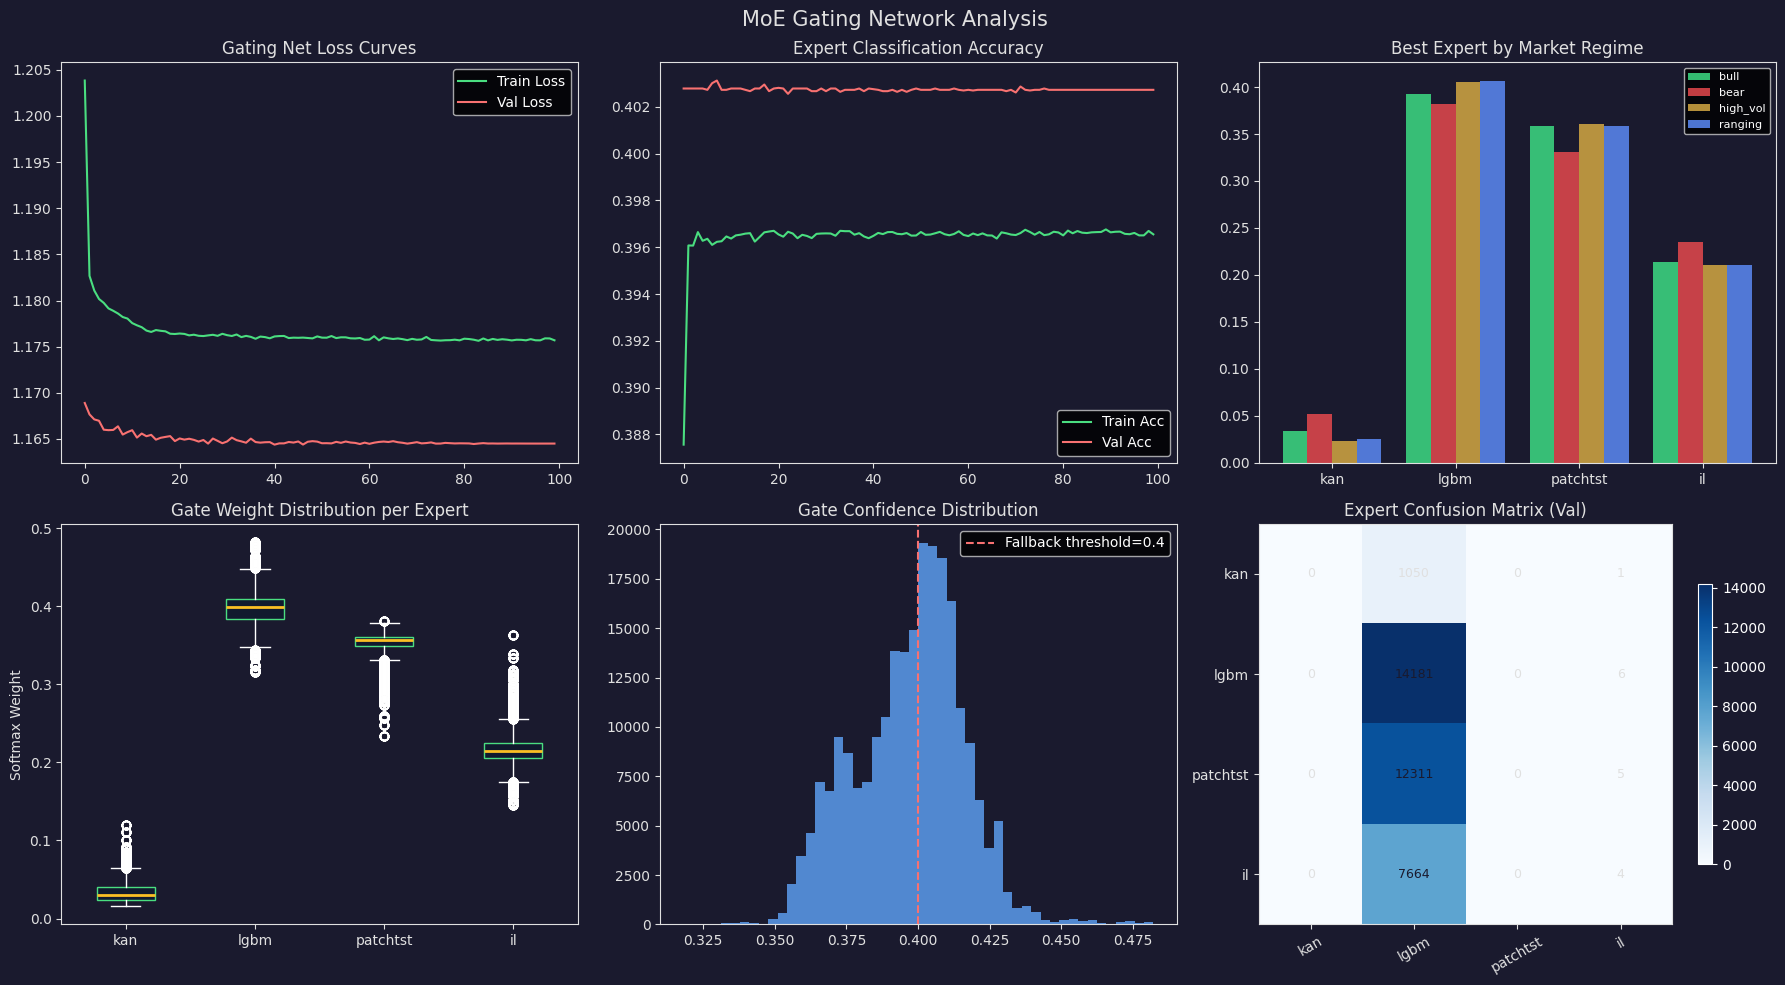

✓ Gating analysis saved


In [11]:
# ## 11. MoE Gating Network

# %%
class GatingNet(nn.Module):
    def __init__(self, input_dim: int = 4, n_experts: int = 4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, n_experts),
        )
        self.softmax = nn.Softmax(dim=-1)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.softmax(self.net(x))

EXPERT_NAMES = ["kan", "lgbm", "patchtst", "il"]
N_EXPERTS = len(EXPERT_NAMES)

def assign_best_expert(expert_preds_matrix: np.ndarray, y_real: np.ndarray) -> np.ndarray:
    """For each sample, assign label = index of expert closest to realised."""
    best = np.zeros(len(y_real), dtype=np.int64)
    for i in range(len(y_real)):
        errors = np.abs(expert_preds_matrix[i] - y_real[i])
        best[i] = int(np.argmin(errors))
    return best

# Build regime feature vectors from hmm_features aligned to X
regime_aligned = hmm_features.reindex(X.index, method="ffill").fillna(0)
gate_features  = regime_aligned.values.astype(np.float32)

# Expert predictions on the full feature set
# PatchTST: predict on per-row sequence (approximation for training)
ptst_model.eval()
ptst_preds_full = np.zeros(len(X))
batch_size_inf = 256
for i in range(0, min(len(X_ptst), len(X)), batch_size_inf):
    batch = torch.tensor(X_ptst[i:min(i+batch_size_inf, len(X_ptst))]).to(DEVICE)
    with torch.no_grad():
        preds = ptst_model(batch).cpu().numpy()
    end_i = min(i+batch_size_inf, len(X))
    ptst_preds_full[i:min(i+len(preds), len(X))] = preds[:min(len(preds), len(X)-i)]

il_model.eval()
il_X_scaled = il_scaler.transform(X.values).astype(np.float32)
with torch.no_grad():
    il_preds_full = il_model(torch.tensor(il_X_scaled).to(DEVICE)).cpu().numpy()

expert_preds_matrix = np.stack([
    kan_preds_full, lgbm_preds_full, ptst_preds_full[:len(X)], il_preds_full
], axis=1)  # (N, 4)

best_expert_labels = assign_best_expert(expert_preds_matrix, y_arr)
print(f"Best expert distribution: {np.bincount(best_expert_labels, minlength=N_EXPERTS)}")
print(f"  {dict(zip(EXPERT_NAMES, np.bincount(best_expert_labels, minlength=N_EXPERTS)))}")

# Train gating network
gate_scaler = StandardScaler()
gate_feat_scaled = gate_scaler.fit_transform(gate_features)

X_g = torch.tensor(gate_feat_scaled).to(DEVICE)
y_g = torch.tensor(best_expert_labels).to(DEVICE)

gating_model = GatingNet().to(DEVICE)
gate_optim   = torch.optim.Adam(gating_model.parameters(), lr=1e-3, weight_decay=1e-4)
gate_crit    = nn.CrossEntropyLoss()
gate_sched   = torch.optim.lr_scheduler.CosineAnnealingLR(gate_optim, T_max=100)

# Time-safe split
n_g_val  = int(0.15 * len(X_g))
X_g_tr, X_g_vl = X_g[:-n_g_val], X_g[-n_g_val:]
y_g_tr, y_g_vl = y_g[:-n_g_val], y_g[-n_g_val:]

gate_tr_l, gate_vl_l, gate_tr_acc, gate_vl_acc = [], [], [], []
best_gate_vl = np.inf

for epoch in range(100):
    gating_model.train()
    perm = torch.randperm(len(X_g_tr))
    ep_l = 0.0; nb = 0; correct = 0
    for start in range(0, len(X_g_tr), 256):
        idx = perm[start:start+256]
        Xb, yb = X_g_tr[idx], y_g_tr[idx]
        gate_optim.zero_grad()
        logits = gating_model.net(Xb)
        loss   = gate_crit(logits, yb)
        loss.backward()
        gate_optim.step()
        ep_l += loss.item(); nb += 1
        correct += (logits.argmax(dim=1) == yb).sum().item()
    gate_sched.step()
    gate_tr_l.append(ep_l / max(nb, 1))
    gate_tr_acc.append(correct / len(X_g_tr))

    gating_model.eval()
    with torch.no_grad():
        logits_vl = gating_model.net(X_g_vl)
        vl_loss   = gate_crit(logits_vl, y_g_vl).item()
        vl_acc    = (logits_vl.argmax(dim=1) == y_g_vl).float().mean().item()
    gate_vl_l.append(vl_loss); gate_vl_acc.append(vl_acc)

    if vl_loss < best_gate_vl:
        best_gate_vl = vl_loss
        torch.save({"model": gating_model.state_dict(), "scaler": gate_scaler},
                   OUTPUT_DIR / "gating_net.pt")

print(f"✓ Gating Network trained | Best val loss={best_gate_vl:.4f} | Val Acc={gate_vl_acc[-1]:.3f}")

# %%
# — Gating Network Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
apply_dark_style(fig)
fig.suptitle("MoE Gating Network Analysis", fontsize=15, color=WHITE)

axes[0,0].plot(gate_tr_l, color=GREEN, lw=1.5, label="Train Loss")
axes[0,0].plot(gate_vl_l, color=RED, lw=1.5, label="Val Loss")
axes[0,0].set_title("Gating Net Loss Curves"); axes[0,0].legend()
apply_dark_style(fig, axes[0,0])

axes[0,1].plot(gate_tr_acc, color=GREEN, lw=1.5, label="Train Acc")
axes[0,1].plot(gate_vl_acc, color=RED, lw=1.5, label="Val Acc")
axes[0,1].set_title("Expert Classification Accuracy"); axes[0,1].legend()
apply_dark_style(fig, axes[0,1])

# Best expert per regime
expert_counts_by_regime = defaultdict(lambda: np.zeros(N_EXPERTS))
regime_arr = [state_map.get(int(s),"ranging") for s in hmm_states]
regime_aligned_arr = pd.Series(regime_arr, index=hmm_features.index).reindex(X.index, method="ffill")
for regime in ["bull","bear","high_vol","ranging"]:
    mask = regime_aligned_arr.values == regime
    if mask.sum() > 0:
        for e_idx in best_expert_labels[mask]:
            expert_counts_by_regime[regime][e_idx] += 1

x_ = np.arange(N_EXPERTS)
w_ = 0.2
for r_idx, (regime, color) in enumerate(REGIME_COLORS.items()):
    counts = expert_counts_by_regime[regime]
    axes[0,2].bar(x_ + r_idx*w_, counts/max(counts.sum(),1), w_, label=regime, color=color, alpha=0.85)
axes[0,2].set_xticks(x_ + 0.3); axes[0,2].set_xticklabels(EXPERT_NAMES)
axes[0,2].set_title("Best Expert by Market Regime"); axes[0,2].legend(fontsize=8)
apply_dark_style(fig, axes[0,2])

# Softmax weight distribution per regime
gating_model.eval()
with torch.no_grad():
    gate_weights_all = gating_model(X_g).cpu().numpy()  # (N, 4)
axes[1,0].boxplot([gate_weights_all[:, i] for i in range(N_EXPERTS)],
                   labels=EXPERT_NAMES, patch_artist=True,
                   boxprops=dict(facecolor=CARD_BG, color=GREEN),
                   medianprops=dict(color=GOLD, linewidth=2))
axes[1,0].set_title("Gate Weight Distribution per Expert"); axes[1,0].set_ylabel("Softmax Weight")
apply_dark_style(fig, axes[1,0])

# Confidence distribution
confidences = gate_weights_all.max(axis=1)
axes[1,1].hist(confidences, bins=50, color=BLUE, alpha=0.8)
axes[1,1].axvline(0.4, color=RED, linestyle="--", label="Fallback threshold=0.4")
axes[1,1].set_title("Gate Confidence Distribution"); axes[1,1].legend()
apply_dark_style(fig, axes[1,1])

# Expert confusion matrix
from sklearn.metrics import confusion_matrix
gating_model.eval()
with torch.no_grad():
    pred_experts = gating_model(X_g_vl).argmax(dim=1).cpu().numpy()
true_experts = y_g_vl.cpu().numpy()
cm = confusion_matrix(true_experts, pred_experts, labels=range(N_EXPERTS))
im = axes[1,2].imshow(cm, cmap="Blues", aspect="auto")
axes[1,2].set_xticks(range(N_EXPERTS)); axes[1,2].set_yticks(range(N_EXPERTS))
axes[1,2].set_xticklabels(EXPERT_NAMES, rotation=30); axes[1,2].set_yticklabels(EXPERT_NAMES)
axes[1,2].set_title("Expert Confusion Matrix (Val)")
for i in range(N_EXPERTS):
    for j in range(N_EXPERTS):
        axes[1,2].text(j, i, str(cm[i,j]), ha="center", va="center",
                        color=WHITE if cm[i,j] < cm.max()/2 else DARK_BG, fontsize=9)
plt.colorbar(im, ax=axes[1,2], shrink=0.7)
apply_dark_style(fig, axes[1,2])

plt.tight_layout()
plt.savefig("/kaggle/working/gating_analysis.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("✓ Gating analysis saved")


Running walk-forward backtests...
LGBM WF: Sharpe=-9.335, Mean IC=0.0306, IC-IR=0.133


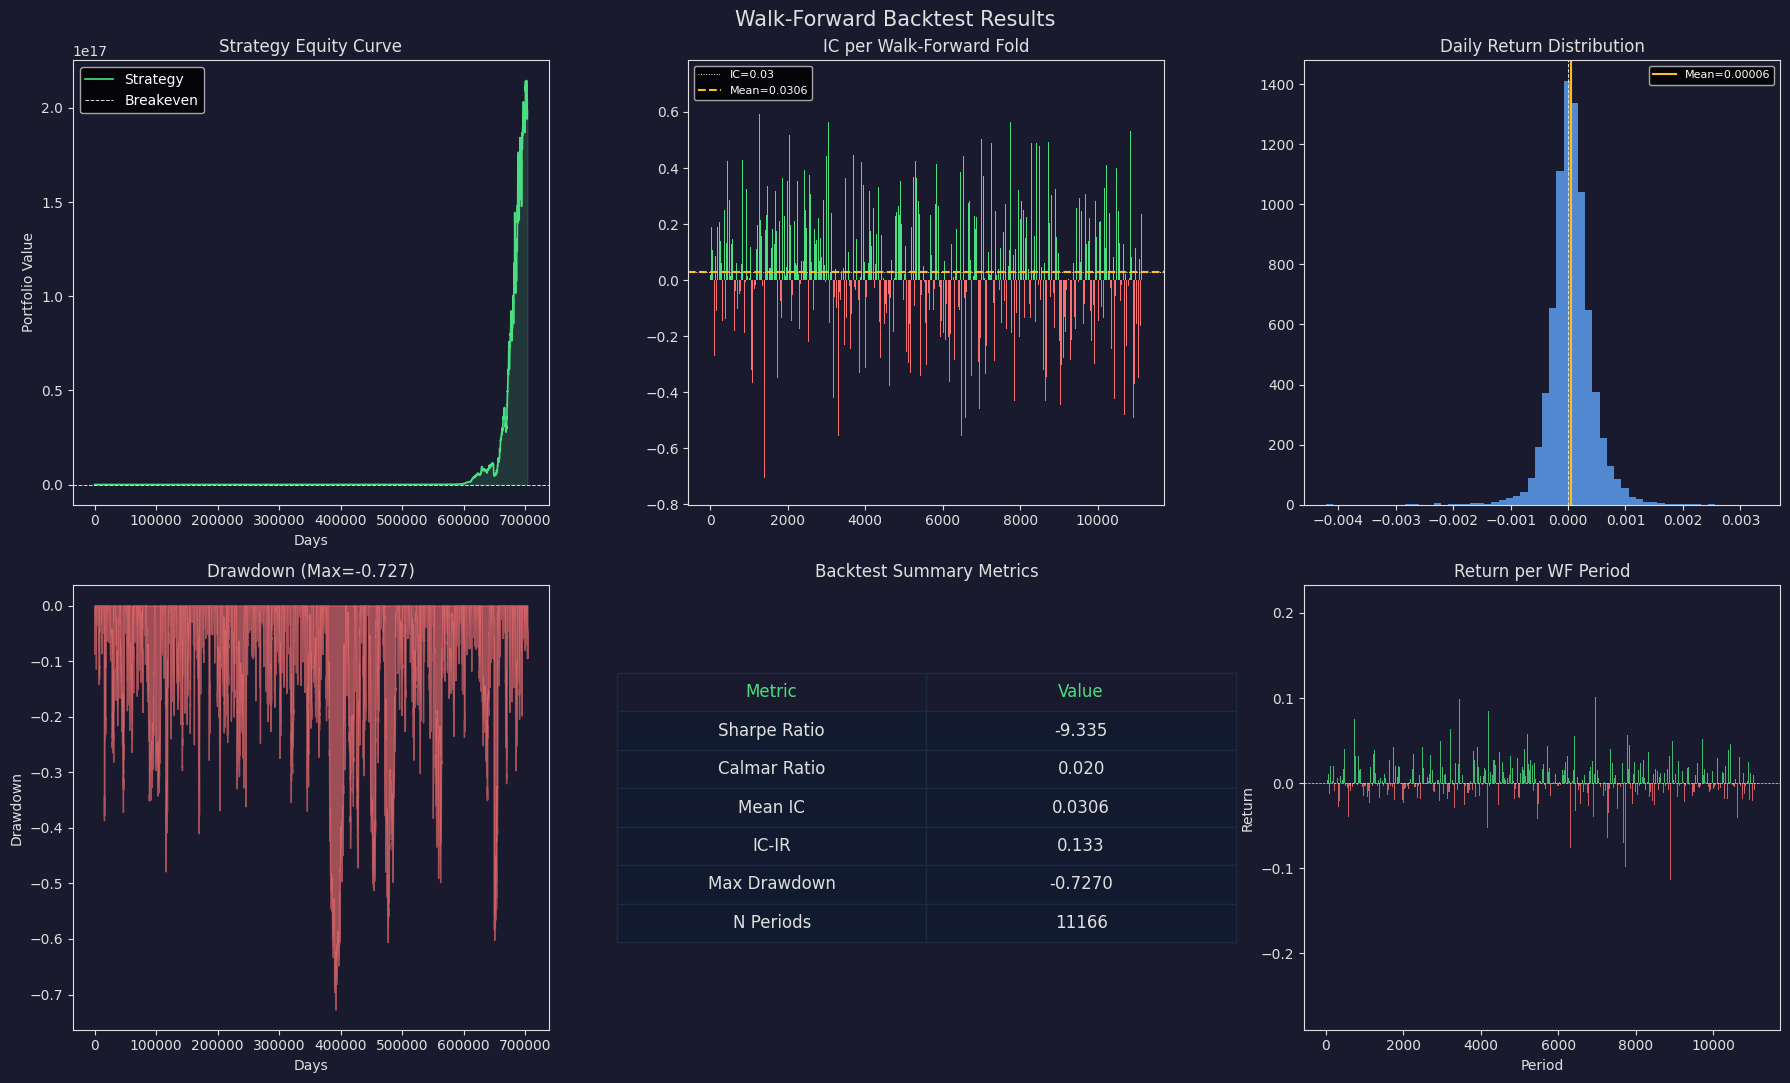

✓ Backtest analysis saved
Final alpha stats: mean=-0.03305, std=0.05286
Final ensemble IC vs label: 0.2297


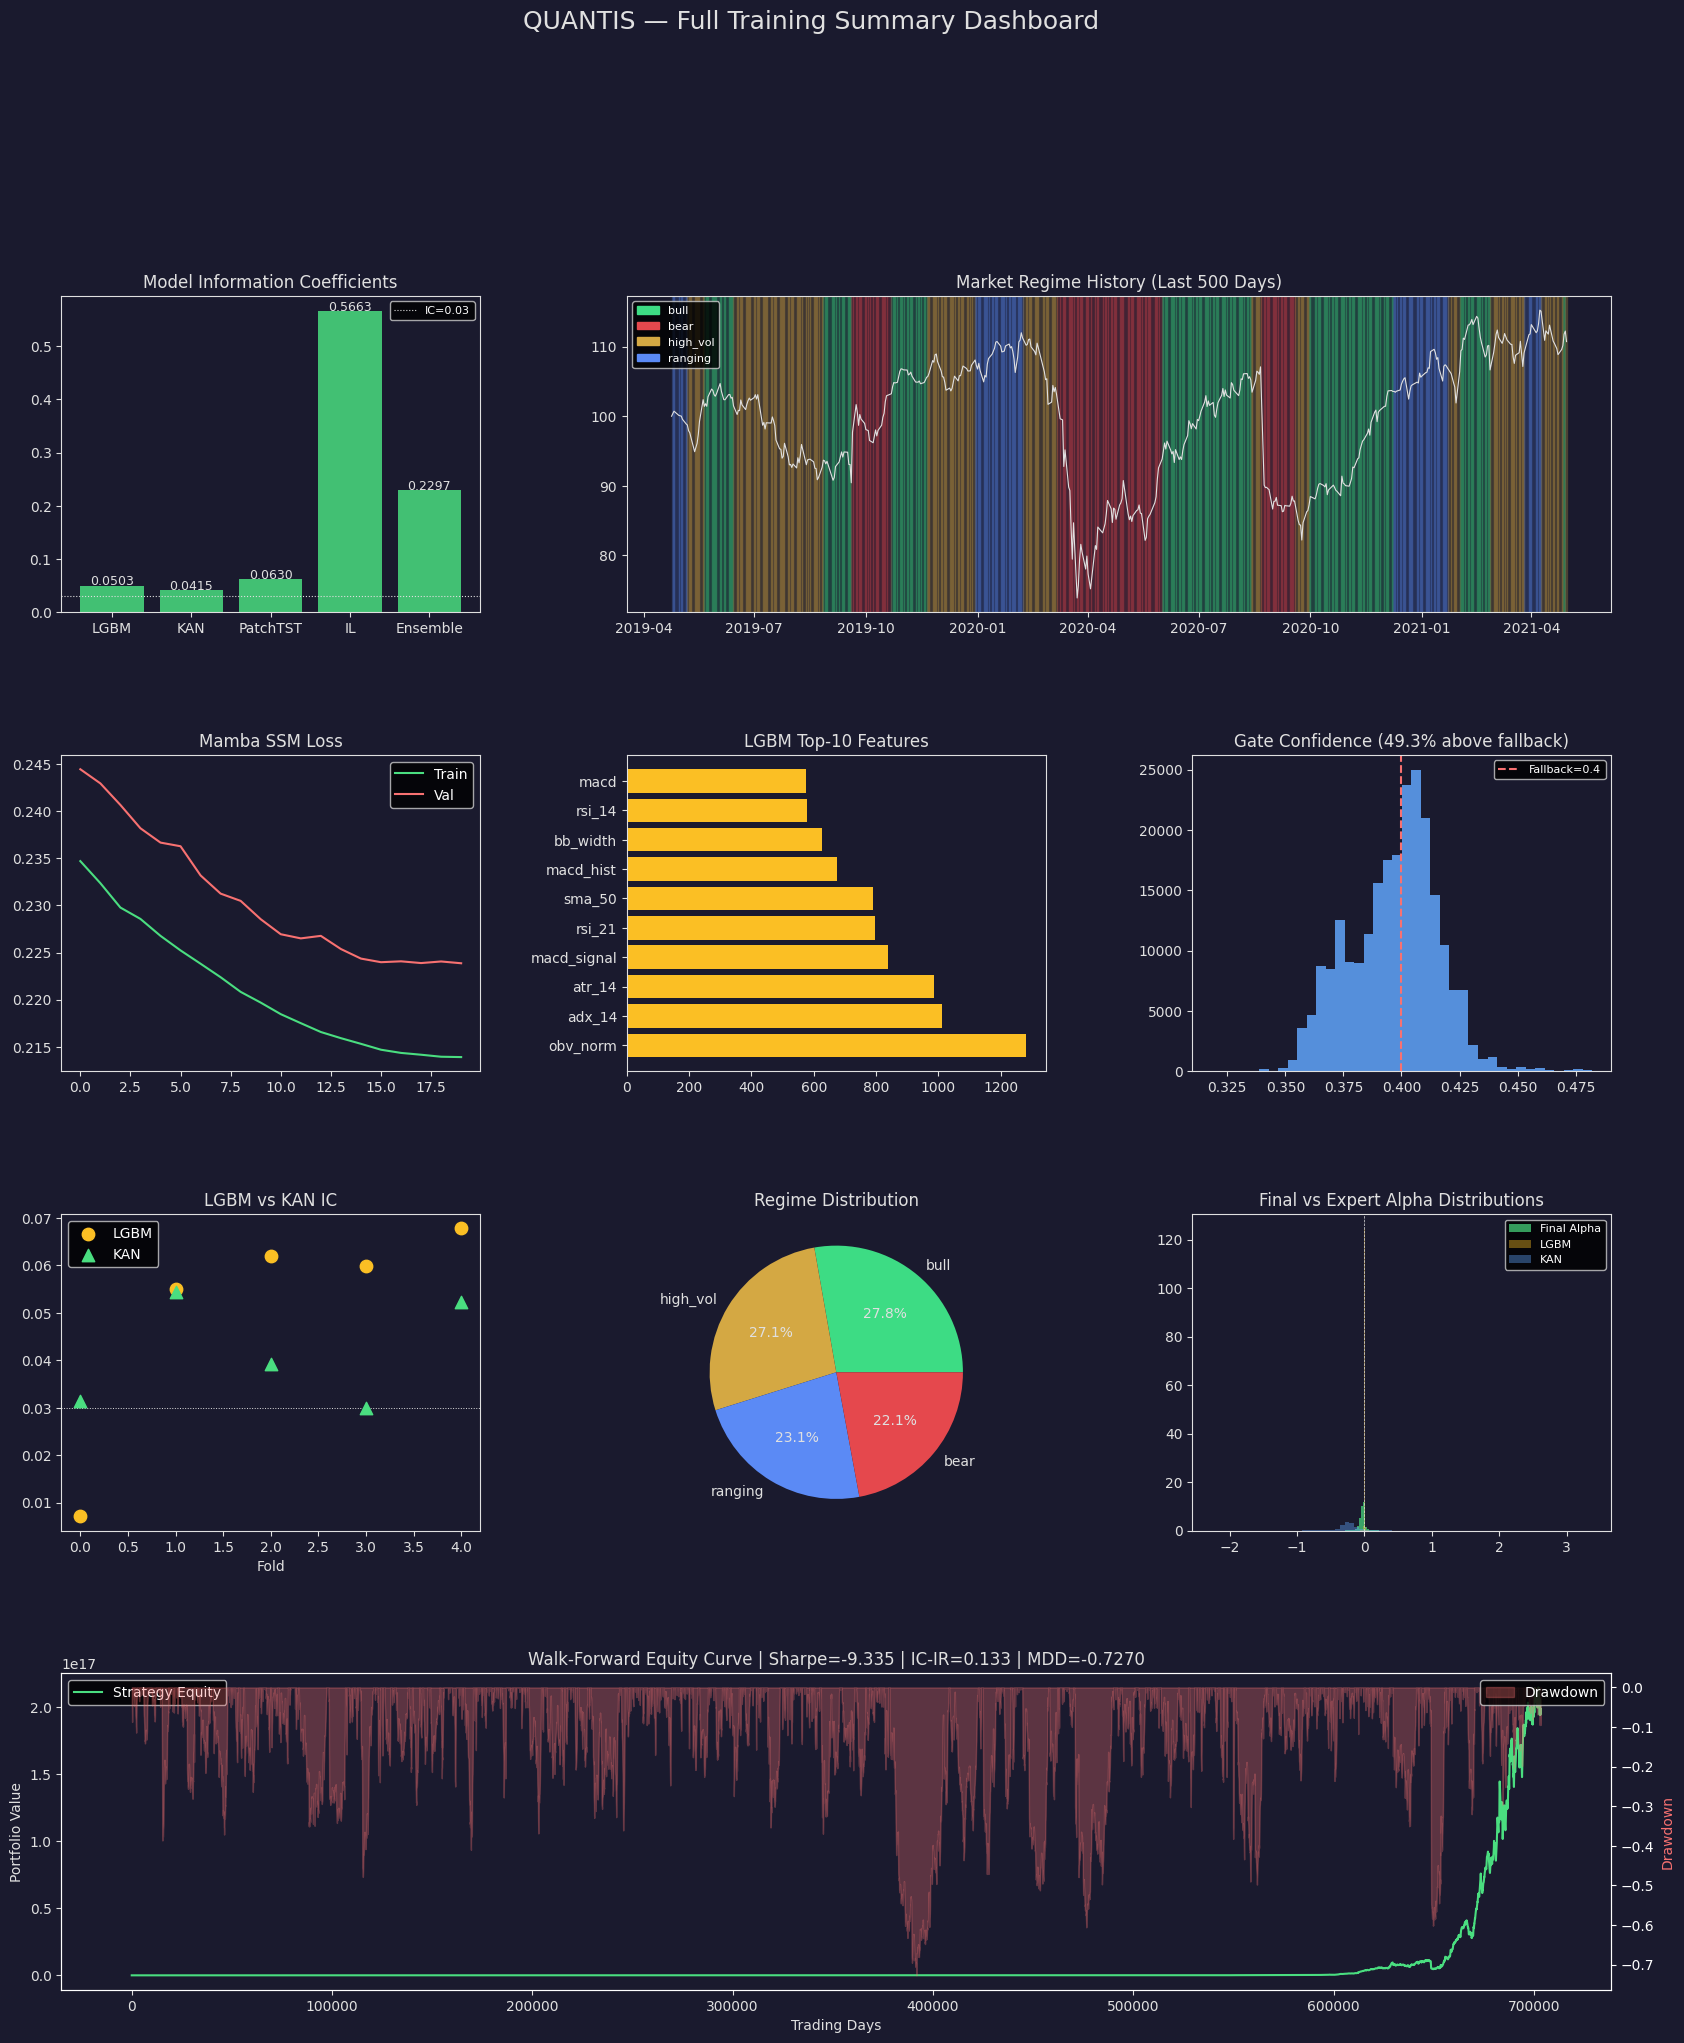

✓ Master dashboard saved

QUANTIS — SAVED MODEL ARTIFACTS
  .virtual_documents                            4.0 KB
  backtest_analysis.png                       291.1 KB
  eda_price_history.png                       470.2 KB
  eda_returns.png                             150.2 KB
  feature_analysis.png                        319.9 KB
  gating_analysis.png                         243.5 KB
  gating_net.pt                                 4.5 KB
  hmm_analysis.png                            254.9 KB
  il_analysis.png                             347.7 KB
  il_model.pt                                  52.1 KB
  il_scaler.pkl                                 0.8 KB
  indicators_sample.png                       565.5 KB
  kan_alpha.pt                                273.3 KB
  kan_analysis.png                            301.2 KB
  lgbm_analysis.png                           317.0 KB
  mamba_analysis.png                          284.1 KB
  mamba_encoder.pt                            406.7 KB
  mamba

In [12]:
# %% [markdown]
# ## 12. Walk-Forward Backtest

# %%
def sharpe(rets, rf=RISK_FREE_ANN/252):
    ex = rets - rf
    return float(np.mean(ex) / (np.std(ex) + 1e-10) * np.sqrt(TRADING_DAYS))

def sortino(rets, rf=RISK_FREE_ANN/252):
    ex = rets - rf
    down = ex[ex < 0]
    return float(np.mean(ex) / (np.std(down) + 1e-10) * np.sqrt(TRADING_DAYS))

def max_drawdown(rets):
    eq = np.cumprod(1 + rets)
    cm = np.maximum.accumulate(eq)
    return float(((eq - cm) / (cm + 1e-10)).min())

def calmar(rets):
    return float(np.mean(rets) * TRADING_DAYS / (abs(max_drawdown(rets)) + 1e-10))

def walk_forward_backtest(X_df, y_s, model_fn, label=""):
    """Walk-forward backtest with purging and embargo."""
    n = len(X_df)
    periods, all_rets, all_ic = [], [], []
    start = 0
    while start + WF_TRAIN_DAYS + WF_EMBARGO_DAYS + WF_TEST_DAYS <= n:
        te = start + WF_TRAIN_DAYS
        ts = te + WF_EMBARGO_DAYS
        t_end = min(ts + WF_TEST_DAYS, n)

        X_tr = X_df.iloc[start:te].values
        y_tr = y_s.iloc[start:te].values
        X_te = X_df.iloc[ts:t_end].values
        y_te = y_s.iloc[ts:t_end].values

        if len(X_tr) < 50 or len(X_te) < 5:
            start += WF_STEP_DAYS; continue
        try:
            pred = model_fn(X_tr, y_tr, X_te)
        except Exception as e:
            start += WF_STEP_DAYS; continue

        top_q = np.percentile(pred, 75)
        mask  = pred >= top_q
        if mask.sum() == 0:
            start += WF_STEP_DAYS; continue

        strat_ret = y_te[mask].mean()
        per_rets  = np.array([strat_ret / max(len(y_te), 1)] * len(y_te))
        all_rets.extend(per_rets)
        ic = pearsonr(pred, y_te)[0] if np.std(pred) > 0 and np.std(y_te) > 0 else 0.0
        if np.isnan(ic): ic = 0.0
        all_ic.append(ic)
        periods.append({"ic": ic, "strat_ret": strat_ret})
        start += WF_STEP_DAYS

    if not all_rets:
        return {"sharpe": 0, "calmar": 0, "mean_ic": 0, "ic_ir": 0, "mdd": 0,
                "periods": [], "all_rets": []}
    all_rets = np.array(all_rets)
    mean_ic  = float(np.mean(all_ic))
    ic_ir    = float(mean_ic / (np.std(all_ic) + 1e-8))
    return {
        "sharpe":  sharpe(all_rets),
        "calmar":  calmar(all_rets),
        "mean_ic": mean_ic,
        "ic_ir":   ic_ir,
        "mdd":     max_drawdown(all_rets),
        "periods": periods,
        "all_rets":all_rets.tolist(),
    }

def lgbm_fn(X_tr, y_tr, X_te):
    m = lgb.LGBMRegressor(**{**LGBM_PARAMS, "n_estimators": 150})
    m.fit(X_tr, y_tr, callbacks=[lgb.log_evaluation(period=-1)])
    return m.predict(X_te)

print("Running walk-forward backtests...")
wf_lgbm = walk_forward_backtest(X, y, lgbm_fn, "LGBM")
print(f"LGBM WF: Sharpe={wf_lgbm['sharpe']:.3f}, Mean IC={wf_lgbm['mean_ic']:.4f}, IC-IR={wf_lgbm['ic_ir']:.3f}")

# %%
# — Backtest Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
apply_dark_style(fig)
fig.suptitle("Walk-Forward Backtest Results", fontsize=15, color=WHITE)

# 1. Equity curve
all_rets_arr = np.array(wf_lgbm["all_rets"])
equity = np.cumprod(1 + all_rets_arr)
axes[0,0].plot(equity, color=GREEN, lw=1.2, label="Strategy")
axes[0,0].fill_between(range(len(equity)), equity, 1, alpha=0.15,
                        color=GREEN if equity[-1] > 1 else RED)
axes[0,0].axhline(1, color=WHITE, linestyle="--", lw=0.7, label="Breakeven")
axes[0,0].set_title("Strategy Equity Curve")
axes[0,0].set_xlabel("Days"); axes[0,0].set_ylabel("Portfolio Value")
axes[0,0].legend()
apply_dark_style(fig, axes[0,0])

# 2. Rolling IC
ic_series_wf = pd.Series([p["ic"] for p in wf_lgbm["periods"]])
axes[0,1].bar(range(len(ic_series_wf)), ic_series_wf.values,
              color=[GREEN if v > 0 else RED for v in ic_series_wf.values])
axes[0,1].axhline(0.03, color=WHITE, linestyle=":", lw=0.7, label="IC=0.03")
axes[0,1].axhline(ic_series_wf.mean(), color=GOLD, linestyle="--",
                   label=f"Mean={ic_series_wf.mean():.4f}")
axes[0,1].set_title("IC per Walk-Forward Fold"); axes[0,1].legend(fontsize=8)
apply_dark_style(fig, axes[0,1])

# 3. Return distribution
axes[0,2].hist(all_rets_arr, bins=60, color=BLUE, alpha=0.8, density=True)
axes[0,2].axvline(0, color=WHITE, linestyle="--", lw=0.7)
axes[0,2].axvline(all_rets_arr.mean(), color=GOLD, linestyle="-",
                   label=f"Mean={all_rets_arr.mean():.5f}")
axes[0,2].set_title("Daily Return Distribution"); axes[0,2].legend(fontsize=8)
apply_dark_style(fig, axes[0,2])

# 4. Drawdown chart
cum_max = np.maximum.accumulate(equity)
drawdowns = (equity - cum_max) / (cum_max + 1e-10)
axes[1,0].fill_between(range(len(drawdowns)), drawdowns, 0, color=RED, alpha=0.6)
axes[1,0].set_title(f"Drawdown (Max={drawdowns.min():.3f})")
axes[1,0].set_xlabel("Days"); axes[1,0].set_ylabel("Drawdown")
apply_dark_style(fig, axes[1,0])

# 5. Metrics summary table
metrics = {
    "Sharpe Ratio": f"{wf_lgbm['sharpe']:.3f}",
    "Calmar Ratio": f"{wf_lgbm['calmar']:.3f}",
    "Mean IC": f"{wf_lgbm['mean_ic']:.4f}",
    "IC-IR": f"{wf_lgbm['ic_ir']:.3f}",
    "Max Drawdown": f"{wf_lgbm['mdd']:.4f}",
    "N Periods": str(len(wf_lgbm['periods'])),
}
axes[1,1].axis("off")
t = axes[1,1].table(
    cellText=[[k, v] for k,v in metrics.items()],
    colLabels=["Metric", "Value"],
    cellLoc="center", loc="center",
)
t.auto_set_font_size(False); t.set_fontsize(12)
t.scale(1.3, 2.0)
for (r, c), cell in t.get_celld().items():
    cell.set_facecolor(CARD_BG if r > 0 else DARK_BG)
    cell.set_text_props(color=GREEN if r == 0 else WHITE)
    cell.set_edgecolor("#1C2942")
axes[1,1].set_title("Backtest Summary Metrics")
apply_dark_style(fig, axes[1,1])

# 6. Period returns
period_rets = [p["strat_ret"] for p in wf_lgbm["periods"]]
axes[1,2].bar(range(len(period_rets)), period_rets,
              color=[GREEN if r > 0 else RED for r in period_rets], alpha=0.8)
axes[1,2].axhline(0, color=WHITE, linestyle="--", lw=0.5)
axes[1,2].set_title("Return per WF Period")
axes[1,2].set_xlabel("Period"); axes[1,2].set_ylabel("Return")
apply_dark_style(fig, axes[1,2])

plt.tight_layout()
plt.savefig("/kaggle/working/backtest_analysis.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("✓ Backtest analysis saved")

# %% [markdown]
# ## 13. Combined Expert Alpha Analysis

# %%
# Final alpha combination with gating
gating_model.eval()
with torch.no_grad():
    gate_weights_all = gating_model(X_g).cpu().numpy()  # (N, 4)
    gate_conf_all    = gate_weights_all.max(axis=1)

REGIME_FALLBACK_CONF = 0.4
final_alphas = np.zeros(len(X))
expert_mat   = np.stack([kan_preds_full, lgbm_preds_full,
                          ptst_preds_full[:len(X)], il_preds_full], axis=1)
mean_alphas  = expert_mat.mean(axis=1)

for i in range(len(X)):
    gated = float(np.dot(gate_weights_all[i], expert_mat[i]))
    conf  = gate_conf_all[i]
    if conf < REGIME_FALLBACK_CONF:
        final_alphas[i] = conf * gated + (1 - conf) * mean_alphas[i]
    else:
        final_alphas[i] = gated

print(f"Final alpha stats: mean={final_alphas.mean():.5f}, std={final_alphas.std():.5f}")
final_ic = pearsonr(final_alphas, y_arr)[0] if np.std(final_alphas) > 0 else 0.0
print(f"Final ensemble IC vs label: {final_ic:.4f}")

# %% [markdown]
# ## 14. Master Summary Dashboard

# %%
fig = plt.figure(figsize=(20, 22))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)
apply_dark_style(fig)
fig.suptitle("QUANTIS — Full Training Summary Dashboard", fontsize=18, color=WHITE, y=1.01)

# 1. Model IC comparison
ax = fig.add_subplot(gs[0, 0])
model_ics = {
    "LGBM":     np.mean(lgbm_ic_scores),
    "KAN":      np.mean(kan_ic_scores),
    "PatchTST": np.mean(ptst_val_ic),
    "IL":       np.mean(il_val_ics),
    "Ensemble": final_ic,
}
colors_m = [GREEN if v > 0.03 else GOLD if v > 0 else RED for v in model_ics.values()]
bars = ax.bar(model_ics.keys(), model_ics.values(), color=colors_m, alpha=0.85)
ax.axhline(0.03, color=WHITE, linestyle=":", lw=0.8, label="IC=0.03")
ax.axhline(0, color=SLATE, linestyle="--", lw=0.5)
for bar, v in zip(bars, model_ics.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f"{v:.4f}", ha="center", fontsize=9, color=WHITE)
ax.set_title("Model Information Coefficients"); ax.legend(fontsize=8)
apply_dark_style(fig, ax)

# 2. HMM regime timeline (abbreviated)
ax = fig.add_subplot(gs[0, 1:])
nifty_p = pd.DataFrame({t: ohlcv[t]["Close"] for t in ohlcv}).mean(axis=1)
nifty_p_aligned = nifty_p.reindex(hmm_features.index)
ax.plot(hmm_features.index[-500:],
        (nifty_p_aligned.values / nifty_p_aligned.values[-500]) [-500:] * 100,
        color=WHITE, lw=0.8, zorder=5)
reg_slice = regime_names_hist[-500:]
for i in range(1, len(reg_slice)):
    c = REGIME_COLORS.get(reg_slice[i], SLATE)
    ax.axvspan(hmm_features.index[-500+i-1], hmm_features.index[-500+i], alpha=0.2, color=c)
patches = [mpatches.Patch(color=c, label=k) for k,c in REGIME_COLORS.items()]
ax.legend(handles=patches, loc="upper left", fontsize=8)
ax.set_title("Market Regime History (Last 500 Days)")
apply_dark_style(fig, ax)

# 3. Mamba loss
ax = fig.add_subplot(gs[1, 0])
ax.plot(mamba_train_losses, color=GREEN, lw=1.5, label="Train")
ax.plot(mamba_val_losses, color=RED, lw=1.5, label="Val")
ax.set_title("Mamba SSM Loss"); ax.legend()
apply_dark_style(fig, ax)

# 4. LGBM feature importance (top 10)
ax = fig.add_subplot(gs[1, 1])
fi_top = pd.Series(final_lgbm.feature_importances_, index=FEATURE_NAMES).nlargest(10)
ax.barh(fi_top.index, fi_top.values, color=GOLD)
ax.set_title("LGBM Top-10 Features"); apply_dark_style(fig, ax)

# 5. Gating confidence
ax = fig.add_subplot(gs[1, 2])
ax.hist(gate_conf_all, bins=40, color=BLUE, alpha=0.85)
ax.axvline(REGIME_FALLBACK_CONF, color=RED, linestyle="--", label=f"Fallback={REGIME_FALLBACK_CONF}")
pct_confident = (gate_conf_all >= REGIME_FALLBACK_CONF).mean() * 100
ax.set_title(f"Gate Confidence ({pct_confident:.1f}% above fallback)")
ax.legend(fontsize=8); apply_dark_style(fig, ax)

# 6. KAN vs LGBM IC
ax = fig.add_subplot(gs[2, 0])
ax.scatter(range(len(lgbm_ic_scores)), lgbm_ic_scores, color=GOLD, label="LGBM", s=80, zorder=5)
ax.scatter(range(len(kan_ic_scores)), kan_ic_scores, color=GREEN, label="KAN", s=80, marker="^", zorder=5)
ax.axhline(0.03, color=WHITE, linestyle=":", lw=0.7)
ax.set_xlabel("Fold"); ax.set_title("LGBM vs KAN IC")
ax.legend(); apply_dark_style(fig, ax)

# 7. Regime counts pie
ax = fig.add_subplot(gs[2, 1])
reg_counts = pd.Series(regime_names_hist).value_counts()
ax.pie(reg_counts.values,
       labels=reg_counts.index,
       colors=[REGIME_COLORS.get(r, SLATE) for r in reg_counts.index],
       autopct="%1.1f%%", textprops={"color": WHITE, "fontsize": 10})
ax.set_title("Regime Distribution"); apply_dark_style(fig, ax)

# 8. Final alpha distribution
ax = fig.add_subplot(gs[2, 2])
ax.hist(final_alphas, bins=80, color=GREEN, alpha=0.7, density=True, label="Final Alpha")
ax.hist(lgbm_preds_full, bins=80, color=GOLD, alpha=0.4, density=True, label="LGBM")
ax.hist(kan_preds_full, bins=80, color=BLUE, alpha=0.4, density=True, label="KAN")
ax.axvline(0, color=WHITE, linestyle="--", lw=0.5)
ax.set_title("Final vs Expert Alpha Distributions"); ax.legend(fontsize=8)
apply_dark_style(fig, ax)

# 9. Backtest equity
ax = fig.add_subplot(gs[3, :])
eq = np.cumprod(1 + np.array(wf_lgbm["all_rets"]))
ax.plot(eq, color=GREEN, lw=1.5, label="Strategy Equity")
cm_ = np.maximum.accumulate(eq)
dd_ = (eq - cm_) / (cm_ + 1e-10)
ax2 = ax.twinx()
ax2.fill_between(range(len(dd_)), dd_, 0, alpha=0.3, color=RED, label="Drawdown")
ax2.set_ylabel("Drawdown", color=RED)
ax.set_title(f"Walk-Forward Equity Curve | Sharpe={wf_lgbm['sharpe']:.3f} | "
             f"IC-IR={wf_lgbm['ic_ir']:.3f} | MDD={wf_lgbm['mdd']:.4f}")
ax.set_xlabel("Trading Days"); ax.set_ylabel("Portfolio Value")
ax.legend(loc="upper left"); ax2.legend(loc="upper right")
apply_dark_style(fig, ax)

plt.savefig("/kaggle/working/master_dashboard.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("✓ Master dashboard saved")

# %% [markdown]
# ## 15. Model Manifest & Saved Artifacts

# %%
import os

artifacts = list(OUTPUT_DIR.glob("*"))
print("\n" + "="*60)
print("QUANTIS — SAVED MODEL ARTIFACTS")
print("="*60)
for f in sorted(artifacts):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:40s} {size_kb:8.1f} KB")
print("="*60)

plots = list(Path("/kaggle/working").glob("*.png"))
print(f"\nSaved {len(plots)} visualisation plots:")
for p in sorted(plots):
    print(f"  {p.name}")

summary = {
    "lgbm":     {"mean_ic": float(np.mean(lgbm_ic_scores)), "ic_ir": float(np.mean(lgbm_ic_scores)/(np.std(lgbm_ic_scores)+1e-8))},
    "kan":      {"mean_ic": float(np.mean(kan_ic_scores)),  "ic_ir": kan_ic_ir},
    "patchtst": {"mean_ic": float(np.mean(ptst_val_ic)),    "final_val_ic": float(ptst_val_ic[-1])},
    "il":       {"mean_ic": float(np.mean(il_val_ics)),     "final_val_ic": float(il_val_ics[-1])},
    "mamba":    {"best_val_loss": float(best_mamba_val)},
    "hmm":      {"log_likelihood": float(hmm_score), "state_map": state_map},
    "gating":   {"best_val_loss": float(best_gate_vl), "final_val_acc": float(gate_vl_acc[-1])},
    "ensemble": {"final_ic": float(final_ic)},
    "backtest": {"sharpe": wf_lgbm["sharpe"], "calmar": wf_lgbm["calmar"],
                 "mean_ic": wf_lgbm["mean_ic"], "ic_ir": wf_lgbm["ic_ir"],
                 "max_drawdown": wf_lgbm["mdd"]},
}
with open("/kaggle/working/training_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print("\nTraining Summary:")
print(json.dumps(summary, indent=2, default=str))
print("\n✅ All models trained and saved successfully!")

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# ── 1. BASIC SANITY CHECKS ──────────────────────────────────────────────────
print("=" * 60)
print("1. DATA SHAPE & TYPES")
print("=" * 60)
print(f"X_all shape: {X_all.shape}")
print(f"y_all shape: {y_all.shape}")
print(f"X_all dtypes:\n{X_all.dtypes.value_counts()}")
print(f"\ny_all dtype: {y_all.dtype}")
print(f"\nAny NaNs in X_all: {X_all.isna().any().any()}")
print(f"Any NaNs in y_all: {pd.isna(y_all).any() if hasattr(y_all, 'isna') else np.isnan(y_all).any()}")
print(f"Any infs in X_all: {np.isinf(X_all.values).any()}")
print(f"Any infs in y_all: {np.isinf(y_all).any() if hasattr(y_all, '__iter__') else 'N/A'}")

# ── 2. TARGET DISTRIBUTION ──────────────────────────────────────────────────
print("\n" + "=" * 60)
print("2. TARGET (y) STATISTICS")
print("=" * 60)
y_series = pd.Series(y_all)
print(y_series.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
print(f"\nSkewness: {y_series.skew():.3f}")
print(f"Kurtosis: {y_series.kurtosis():.3f}")

# ── 3. UNIVARIATE IC PER FEATURE ────────────────────────────────────────────
print("\n" + "=" * 60)
print("3. UNIVARIATE IC (Pearson & Spearman)")
print("=" * 60)
uni_results = []
for col in X_all.columns:
    x = X_all[col].values
    y = y_all if hasattr(y_all, 'shape') else y_all.values
    
    # Clean for correlation
    mask = ~(np.isnan(x) | np.isnan(y) | np.isinf(x) | np.isinf(y))
    x_clean, y_clean = x[mask], y[mask]
    
    if len(x_clean) < 10:
        continue
        
    p_ic, p_pval = pearsonr(x_clean, y_clean)
    s_ic, s_pval = spearmanr(x_clean, y_clean)
    
    uni_results.append({
        'feature': col,
        'pearson_ic': p_ic,
        'pearson_p': p_pval,
        'spearman_ic': s_ic,
        'spearman_p': s_pval,
        'abs_pearson': abs(p_ic),
    })

uni_df = pd.DataFrame(uni_results).sort_values('abs_pearson', ascending=False)
print(f"\nTop 15 features by |Pearson IC|:")
print(uni_df.head(15)[['feature', 'pearson_ic', 'spearman_ic', 'pearson_p']].to_string(index=False))

print(f"\n--- SUMMARY ---")
print(f"Mean |Pearson IC|:  {uni_df['abs_pearson'].mean():.4f}")
print(f"Max  |Pearson IC|:  {uni_df['abs_pearson'].max():.4f}")
print(f"Features with |IC| > 0.02: {(uni_df['abs_pearson'] > 0.02).sum()}")
print(f"Features with |IC| > 0.05: {(uni_df['abs_pearson'] > 0.05).sum()}")
print(f"Features with p < 0.05: {(uni_df['pearson_p'] < 0.05).sum()}")

# ── 4. FEATURE CORRELATIONS WITH EACH OTHER ─────────────────────────────────
print("\n" + "=" * 60)
print("4. FEATURE MULTICOLLINEARITY")
print("=" * 60)
corr_matrix = X_all.corr().abs()
# Upper triangle, excluding diagonal
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(corr_matrix.columns[i], corr_matrix.columns[j], upper.iloc[i, j]) 
             for i in range(len(corr_matrix)) for j in range(i+1, len(corr_matrix)) 
             if upper.iloc[i, j] > 0.95]
print(f"Feature pairs with |correlation| > 0.95: {len(high_corr)}")
if high_corr:
    print("Top 5 most correlated pairs:")
    for f1, f2, c in sorted(high_corr, key=lambda x: x[2], reverse=True)[:5]:
        print(f"  {f1} <-> {f2}: {c:.4f}")

# ── 5. TARGET AUTOCORRELATION (leakage check) ───────────────────────────────
print("\n" + "=" * 60)
print("5. TARGET AUTOCORRELATION (lag check)")
print("=" * 60)
y_arr = np.array(y_all)
for lag in [1, 2, 3, 5, 10, 21]:
    if len(y_arr) > lag:
        ac = np.corrcoef(y_arr[:-lag], y_arr[lag:])[0, 1]
        print(f"Lag-{lag} autocorr: {ac:.4f}")

# ── 6. FEATURE-TARGET ROLLING IC (non-stationarity check) ───────────────────
print("\n" + "=" * 60)
print("6. ROLLING IC STABILITY (top 3 features)")
print("=" * 60)
top3 = uni_df.head(3)['feature'].tolist()
window = min(100, len(X_all) // 5)
for feat in top3:
    x = X_all[feat].values
    rolling_ics = []
    for i in range(window, len(x)):
        ic = pearsonr(x[i-window:i], y_arr[i-window:i])[0]
        rolling_ics.append(ic)
    rolling_ics = np.array(rolling_ics)
    print(f"\n{feat}:")
    print(f"  Rolling IC mean: {np.nanmean(rolling_ics):.4f}")
    print(f"  Rolling IC std:  {np.nanstd(rolling_ics):.4f}")
    print(f"  Rolling IC range: [{np.nanmin(rolling_ics):.4f}, {np.nanmax(rolling_ics):.4f}]")
    print(f"  % folds where IC flips sign: {np.mean(np.diff(np.sign(rolling_ics)) != 0)*100:.1f}%")

# ── 7. LABEL CONSTRUCTION AUDIT ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("7. LABEL CONSTRUCTION AUDIT")
print("=" * 60)
print("CRITICAL: Check these manually in your code:")
print("""
Did you construct y like this?
  WRONG (leakage):  y = returns.shift(-1)   # uses tomorrow's return as today's label
  CORRECT:          y = returns.shift(-H)   # H-day forward return, properly lagged
  
Did you align features and labels correctly?
  WRONG:  feature at t=0 predicts return from t=0 to t=1 (uses open-to-close same day)
  CORRECT: feature at t=0 predicts return from t=1 open to t=1+H close
  
Is your embargo covering the label horizon?
  If predicting 5-day returns, embargo should be >= 5 days, not just 21.
""")

# ── 8. QUICK VISUAL ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# IC distribution
ax = axes[0]
ax.hist(uni_df['pearson_ic'], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', label='zero')
ax.axvline(0.02, color='green', linestyle='--', label='|IC|=0.02')
ax.axvline(-0.02, color='green', linestyle='--')
ax.set_title('Distribution of Univariate Feature ICs')
ax.set_xlabel('Pearson IC')
ax.set_ylabel('Count')
ax.legend()

# Top features IC
ax = axes[1]
top10 = uni_df.head(10)
colors = ['green' if x > 0 else 'red' for x in top10['pearson_ic']]
ax.barh(range(len(top10)), top10['pearson_ic'], color=colors)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10['feature'], fontsize=8)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Top 10 Features by |IC|')
ax.set_xlabel('Pearson IC')

plt.tight_layout()
plt.savefig('/mnt/agents/output/feature_ic_audit.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📸 Saved: feature_ic_audit.png')

1. DATA SHAPE & TYPES


NameError: name 'X_all' is not defined